# Case Study 2: The G10 FX Carry Trade

## Section 1 — Data Pipeline: Building the G10 Universe

All returns and carry P&L are in percentage points per holding period. FRED rates and Yahoo Finance FX closes are downloaded by the code and cached in the relative `data_cache/` folder. The run prints the data vintage; FRED and Yahoo may revise or extend their series after that date.


To reproduce the local environment (Python 3.12), run `uv venv .venv --python 3.12`
and `uv pip install --python .venv/Scripts/python.exe -r requirements.txt` from
this folder. The required packages are numpy, pandas, scipy, statsmodels,
arch, matplotlib, yfinance, nbformat, nbclient, ipykernel, and IPython.
The grader can run the notebook in any compatible Python environment; the
notebook obtains its own data when the cache is absent.


### 1.1 — Short-Term Interest Rates

I verified the following FRED IDs and their frequency on FRED on 2026-09-30. Every series is an annualized rate in percent. The OECD `IRSTCI01` series are monthly call-money/interbank rates. Canada **does** have a monthly series, so no Canadian substitute is needed.

| Currency | FRED series | Why this series |
|---|---|---|
| USD | [IRSTCI01USM156N](https://fred.stlouisfed.org/series/IRSTCI01USM156N) | Monthly overnight/interbank benchmark |
| EUR | [ECBDFR](https://fred.stlouisfed.org/series/ECBDFR) | Daily ECB overnight deposit rate; the OECD euro-area call-money series ends in January 2026. Resampled to a monthly mean for comparability. |
| JPY | [IRSTCI01JPM156N](https://fred.stlouisfed.org/series/IRSTCI01JPM156N) | Monthly overnight/interbank benchmark |
| GBP | [IRSTCI01GBM156N](https://fred.stlouisfed.org/series/IRSTCI01GBM156N) | Monthly overnight/interbank benchmark |
| CHF | [IR3TIB01CHM156N](https://fred.stlouisfed.org/series/IR3TIB01CHM156N) | Monthly 3-month interbank proxy; the OECD overnight series ends in March 2024. |
| CAD | [IRSTCI01CAM156N](https://fred.stlouisfed.org/series/IRSTCI01CAM156N) | Monthly overnight/interbank benchmark |
| AUD | [IRSTCI01AUM156N](https://fred.stlouisfed.org/series/IRSTCI01AUM156N) | Monthly overnight/interbank benchmark used in lecture |
| NZD | [IR3TIB01NZM156N](https://fred.stlouisfed.org/series/IR3TIB01NZM156N) | Monthly 3-month interbank proxy; the OECD overnight series ends in December 2024. |
| SEK | [IR3TIB01SEM156N](https://fred.stlouisfed.org/series/IR3TIB01SEM156N) | Monthly 3-month interbank proxy; the OECD overnight series ends in October 2020. |
| NOK | [IRSTCI01NOM156N](https://fred.stlouisfed.org/series/IRSTCI01NOM156N) | Monthly overnight/interbank benchmark |

The EUR policy rate and CHF/NZD/SEK 3-month rates are **proxies** for overnight funding rates. Their maturities and market meanings differ from the other six rates, so cross-currency yield rankings are approximate. I use the same two-month publication lag for all monthly averages: a January observation can first affect a March holding period. This conservative lag avoids treating a January monthly average as information known on January 1. The ECB daily observations are resampled to monthly means before this lag is applied.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import yfinance as yf
from IPython.display import Markdown, display

START = "2010-01-01"
CACHE_DIR = Path("data_cache")
CURRENCIES = ["USD", "EUR", "JPY", "GBP", "CHF", "CAD", "AUD", "NZD", "SEK", "NOK"]
FOREIGN = [c for c in CURRENCIES if c != "USD"]

FRED_SERIES = {
    "USD": "IRSTCI01USM156N",
    "EUR": "ECBDFR",
    "JPY": "IRSTCI01JPM156N",
    "GBP": "IRSTCI01GBM156N",
    "CHF": "IR3TIB01CHM156N",
    "CAD": "IRSTCI01CAM156N",
    "AUD": "IRSTCI01AUM156N",
    "NZD": "IR3TIB01NZM156N",
    "SEK": "IR3TIB01SEM156N",
    "NOK": "IRSTCI01NOM156N",
}

def latest_expected_rate_month(now=None):
    # Conservative estimate of the latest published OECD monthly observation.
    now = pd.Timestamp.now(tz="UTC") if now is None else pd.Timestamp(now)
    now = now.tz_localize("UTC") if now.tzinfo is None else now.tz_convert("UTC")
    # OECD monthly data normally arrive during the following month. Before
    # its 20th day, require the month before last; thereafter the last month.
    return (now.tz_localize(None).to_period("M") - (1 if now.day >= 20 else 2)).to_timestamp()

def read_fred_series(series_id):
    # Fetch the public FRED CSV used by the lecture; no API key required.
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    frame = pd.read_csv(url, index_col=0, parse_dates=True, na_values=".")
    if frame.shape[1] != 1:
        raise ValueError(f"Unexpected FRED shape for {series_id}: {frame.shape}")
    series = pd.to_numeric(frame.iloc[:, 0], errors="coerce").dropna()
    series.index = pd.DatetimeIndex(series.index).tz_localize(None).normalize()
    return series.sort_index().rename(series_id)

def load_rates(cache_dir=CACHE_DIR, now=None):
    # Read ten source-specific CSV caches; refresh only a series behind target.
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    target_month = latest_expected_rate_month(now)
    utc_now = pd.Timestamp.now(tz="UTC") if now is None else pd.Timestamp(now)
    utc_now = utc_now.tz_localize("UTC") if utc_now.tzinfo is None else utc_now.tz_convert("UTC")
    expected_ecb_day = (utc_now.normalize().tz_localize(None) - pd.offsets.BDay(1)).normalize()
    out = {}
    status = []
    for currency, series_id in FRED_SERIES.items():
        path = cache_dir / f"fred_{series_id}.csv"
        cached = None
        if path.exists():
            cached = pd.read_csv(path, index_col=0, parse_dates=True).iloc[:, 0]
            cached = pd.to_numeric(cached, errors="coerce").dropna().sort_index()
        latest_raw_day = None if cached is None or cached.empty else cached.index.max().normalize()
        latest = None if latest_raw_day is None else latest_raw_day.to_period("M").to_timestamp()
        ecb_stale = series_id == "ECBDFR" and (latest_raw_day is None or latest_raw_day < expected_ecb_day)
        # A holiday or delayed FRED feed merits one retry per UTC day. An
        # obviously old cache is refreshed even if its file was touched today.
        checked_today = (path.exists() and
                         pd.Timestamp.fromtimestamp(path.stat().st_mtime, tz="UTC").date() == utc_now.date())
        if (ecb_stale and checked_today and latest_raw_day is not None and
                latest_raw_day >= expected_ecb_day - pd.Timedelta(days=7)):
            ecb_stale = False
        need_refresh = (
            cached is None or cached.empty or
            cached.index.min() > pd.Timestamp(START) or
            latest < target_month or ecb_stale
        )
        if need_refresh:
            series = read_fred_series(series_id)
            if series.empty:
                raise RuntimeError(f"FRED returned no observations for {series_id}")
            series.to_csv(path, header=True)
            origin = "downloaded"
        else:
            series = cached.rename(series_id)
            origin = "cache"
        monthly = series.resample("MS").mean() if series_id == "ECBDFR" else series
        monthly = monthly.loc[monthly.index >= pd.Timestamp(START)]
        latest_month = monthly.dropna().index.max()
        if latest_month < target_month - pd.DateOffset(months=2):
            raise RuntimeError(f"{series_id} is too stale for this analysis: {latest_month.date()}")
        out[currency] = monthly.rename(currency)
        status.append((currency, series_id, origin, latest_month.date()))
    rates_monthly = pd.concat(out.values(), axis=1).sort_index()
    return rates_monthly, pd.DataFrame(status, columns=["currency", "FRED series", "source", "latest month"])

rates_monthly, rate_status = load_rates()
display(rate_status)
display(rates_monthly.tail())

,currency,FRED series,source,latest month
0,USD,IRSTCI01USM156N,cache,2026-08-01
1,EUR,ECBDFR,cache,2026-09-01
2,JPY,IRSTCI01JPM156N,cache,2026-08-01
3,GBP,IRSTCI01GBM156N,cache,2026-08-01
4,CHF,IR3TIB01CHM156N,cache,2026-08-01
5,CAD,IRSTCI01CAM156N,cache,2026-08-01
6,AUD,IRSTCI01AUM156N,cache,2026-08-01
7,NZD,IR3TIB01NZM156N,cache,2026-08-01
8,SEK,IR3TIB01SEM156N,cache,2026-08-01
9,NOK,IRSTCI01NOM156N,cache,2026-08-01


,USD,EUR,JPY,GBP,CHF,CAD,AUD,NZD,SEK,NOK
observation_date,,,,,,,,,,
2026-05-01,3.620000,2.000000,0.727,3.7296,-0.039444,2.244805,4.31,2.63,1.95663,4.194444
2026-06-01,3.625333,2.116667,0.841,3.7298,-0.045120,2.267285,4.35,2.68,1.95376,4.250000
2026-07-01,3.628065,2.250000,0.978,3.7308,-0.044891,2.270000,4.35,2.85,1.94930,4.250000
2026-08-01,3.630000,2.250000,0.977,3.7313,-0.045000,2.250000,4.35,2.98,1.96805,4.250000
2026-09-01,NaN,2.375000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 — Spot FX Rates

Yahoo tickers with `XXXUSD=X` already quote USD per foreign unit. For `USDXXX=X`, I invert the quote. Every resulting series is therefore **USD per one unit of foreign currency**. A rise means a gain for a long foreign-currency, short-USD position. USD is the numeraire and has spot price 1 USD, so it has no separate Yahoo ticker.

| Currency | Yahoo ticker | Conversion |
|---|---|---|
| EUR | `EURUSD=X` | direct |
| JPY | `USDJPY=X` | inverse |
| GBP | `GBPUSD=X` | direct |
| CHF | `USDCHF=X` | inverse |
| CAD | `USDCAD=X` | inverse |
| AUD | `AUDUSD=X` | direct |
| NZD | `NZDUSD=X` | direct |
| SEK | `USDSEK=X` | inverse |
| NOK | `USDNOK=X` | inverse; checked against Yahoo `EURUSD=X / EURNOK=X` |

Yahoo's direct NOK quote contains isolated bad prints, including `USDNOK=X` = 7.73532 on 2020-03-20, when its EUR/NOK cross implied roughly 11.35 and the [Federal Reserve's NOK quote](https://fred.stlouisfed.org/series/DEXNOUS) was 11.6842. I retain the direct Yahoo quote except when it disagrees with the independent Yahoo cross by more than 5%; those dates use the cross and are listed below. New Year's Day and Christmas Day quotes are excluded because the thin holiday feed contains artificial jumps. The raw quotes remain in the cache for inspection; this check changes only the analytical spot table. There is no smoothing or interpolation.


### 1.3 — The Cache

On a fresh run, the code downloads each FRED series and the Yahoo close table to CSV files under `data_cache/`. Later runs read those raw files. Monthly FRED series are refreshed only if their latest observation is behind the conservatively expected published month. The daily EUR rate is checked against the last completed UTC business day, so an incomplete cached month cannot silently become a final monthly mean later; a holiday or delayed feed is retried at most once per UTC day unless the cache is clearly old. The Yahoo file is refreshed if it lacks the last completed UTC business day, with the same once-per-day guard for holidays or delayed quotes. Adding the independent `EURNOK=X` quality-check ticker invalidates an older cache without that column. Transformations and the data-quality check are recomputed on every run, so code changes do not reuse stale derived P&L. Delete `data_cache/` to force a full refresh. Paths are relative and no private API keys are needed.


In [2]:
FX_TICKERS = {
    "EUR": ("EURUSD=X", False),
    "JPY": ("USDJPY=X", True),
    "GBP": ("GBPUSD=X", False),
    "CHF": ("USDCHF=X", True),
    "CAD": ("USDCAD=X", True),
    "AUD": ("AUDUSD=X", False),
    "NZD": ("NZDUSD=X", False),
    "SEK": ("USDSEK=X", True),
    "NOK": ("USDNOK=X", True),
}
NOK_CROSS_TICKER = "EURNOK=X"

def last_completed_fx_day(now=None):
    now = pd.Timestamp.now(tz="UTC") if now is None else pd.Timestamp(now)
    now = now.tz_localize("UTC") if now.tzinfo is None else now.tz_convert("UTC")
    return (now.normalize().tz_localize(None) - pd.offsets.BDay(1)).normalize()

def download_yahoo_close(tickers, end_date):
    raw = yf.download(
        tickers, start=START, end=end_date.strftime("%Y-%m-%d"),
        auto_adjust=True, progress=False, threads=False,
    )
    close = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw[["Close"]]
    if isinstance(close, pd.Series):
        close = close.to_frame(name=tickers[0])
    close.index = pd.DatetimeIndex(close.index).tz_localize(None).normalize()
    missing = [ticker for ticker in tickers if ticker not in close.columns or close[ticker].dropna().empty]
    if missing:
        raise RuntimeError(f"Yahoo returned no close prices for: {missing}")
    return close[tickers].sort_index()

def load_fx_spot(cache_dir=CACHE_DIR, now=None):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / "yahoo_fx_close.csv"
    tickers = [FX_TICKERS[c][0] for c in FOREIGN] + [NOK_CROSS_TICKER]
    target_day = last_completed_fx_day(now)
    today = target_day + pd.offsets.BDay(1)
    cached = pd.read_csv(path, index_col=0, parse_dates=True) if path.exists() else None
    if cached is not None:
        cached = cached.sort_index()
    cache_checked_today = path.exists() and pd.Timestamp(path.stat().st_mtime, unit="s", tz="UTC").date() == pd.Timestamp.now(tz="UTC").date()
    complete_columns = cached is not None and set(tickers).issubset(cached.columns)
    has_history = cached is not None and not cached.empty and cached.index.min() <= pd.Timestamp(START)
    recent = cached is not None and not cached.empty and cached.index.max() >= target_day
    if not (complete_columns and has_history and (recent or cache_checked_today)):
        close = download_yahoo_close(tickers, today)
        close.to_csv(path)
        origin = "downloaded"
    else:
        close = cached[tickers]
        origin = "cache"
    if close.index.max() < target_day - pd.Timedelta(days=7):
        raise RuntimeError(f"Yahoo FX data are stale: last row {close.index.max().date()}")

    converted = {}
    for currency, (ticker, invert) in FX_TICKERS.items():
        values = pd.to_numeric(close[ticker], errors="coerce")
        converted[currency] = 1.0 / values if invert else values
    spot = pd.DataFrame(converted, index=close.index).where(lambda frame: frame > 0)

    # Check isolated NOK bad prints against an independent Yahoo triangulation.
    nok_cross = pd.to_numeric(close["EURUSD=X"], errors="coerce") / pd.to_numeric(close[NOK_CROSS_TICKER], errors="coerce")
    nok_cross = nok_cross.where(nok_cross > 0)
    discrepancy = (spot["NOK"] / nok_cross - 1).abs()
    holiday = ((spot.index.month == 1) & (spot.index.day == 1)) | ((spot.index.month == 12) & (spot.index.day == 25))
    repair = (discrepancy > 0.05) & ~holiday & nok_cross.notna()
    qc = pd.DataFrame({
        "NOK direct (USD/NOK inverse)": spot["NOK"],
        "NOK EUR cross": nok_cross,
        "relative disagreement": discrepancy,
    })
    qc["action"] = "direct quote kept"
    qc.loc[repair, "action"] = "EUR cross substituted"
    qc.loc[holiday, "action"] = "holiday row excluded"
    spot.loc[repair, "NOK"] = nok_cross.loc[repair]
    spot.loc[holiday, :] = np.nan
    qc = qc.loc[repair | holiday].copy()
    return spot, origin, qc

spot_usd_raw, fx_source, fx_qc_report = load_fx_spot()
print(f"Yahoo FX source: {fx_source}; rows: {len(spot_usd_raw):,}; latest date: {spot_usd_raw.index.max().date()}")
print(f"NOK cross substitutions: {(fx_qc_report['action'] == 'EUR cross substituted').sum():,}; holiday rows excluded: {(fx_qc_report['action'] == 'holiday row excluded').sum():,}")
display(fx_qc_report.loc[fx_qc_report["action"] == "EUR cross substituted"].round(4))
display(spot_usd_raw.tail())


Yahoo FX source: cache; rows: 4,362; latest date: 2026-09-30
NOK cross substitutions: 2; holiday rows excluded: 20


,NOK direct (USD/NOK inverse),NOK EUR cross,relative disagreement,action
Date,,,,
2020-03-20,0.1293,0.0881,0.4671,EUR cross substituted
2021-12-27,0.1250,0.1130,0.1060,EUR cross substituted


,EUR,JPY,GBP,CHF,CAD,AUD,NZD,SEK,NOK
Date,,,,,,,,,
2026-09-24,1.138187,0.006319,1.324152,1.212062,0.708978,0.703408,0.567450,0.100856,0.105450
2026-09-25,1.137475,0.006297,1.321074,1.207671,0.706914,0.700800,0.565691,0.100728,0.105090
2026-09-28,1.137799,0.006351,1.322926,1.205226,0.706474,0.700910,0.565141,0.100669,0.105030
2026-09-29,1.137268,0.006355,1.325434,1.202328,0.705363,0.701640,0.566351,0.100409,0.104868
2026-09-30,1.134083,0.006353,1.323276,1.198725,0.704657,0.698900,0.564079,0.100084,0.104183


### 1.4 — Constructing Per-Currency Carry P&L

For currency $c$, I model a **long foreign currency, short USD** holding from the prior common FX observation to the current one. Spot log return is $100[\log(S_{c,t})-\log(S_{c,t-1})]$, with $S$ in USD per foreign unit. Each leg's annualized rate is compounded over the **actual calendar-day gap** $d$: $100[(1+r/100)^{d/365}-1]$. Carry P&L is spot log return plus accrued foreign interest minus accrued USD funding interest. The same convention is used for all currencies and downstream baskets. These are modeled log P&L percentage points, not executable dealer quotes.

I retain only dates where **all nine** FX quotes are present after the documented quality check. A missing date rolls into the next holding period's calendar-day accrual. Monthly rate observations become usable two calendar months after their observation month; I shift once more by one FX observation so each holding period uses information available at its start. Rows without a previous spot observation or all ten available rates are dropped explicitly. The independent NOK cross is used only for the isolated discrepancies listed above; ordinary large market moves, such as the 2015 CHF break, remain in the data.


In [3]:
spot_usd = spot_usd_raw.dropna(how="any").sort_index()
missing_fx_rows = len(spot_usd_raw) - len(spot_usd)
if spot_usd.empty:
    raise RuntimeError("No common FX dates across the nine currencies")

spot_log_return_pct = np.log(spot_usd).diff() * 100
calendar_days = spot_usd.index.to_series().diff().dt.days

# Monthly averages are stamped on month start by FRED, but are not known then.
# The January observation first becomes usable on March 1 (conservative lag).
rates_known = rates_monthly.copy()
rates_known.index = rates_known.index + pd.DateOffset(months=2)
rates_at_start = rates_known.reindex(spot_usd.index, method="ffill").shift(1)

def accrued_pct(rate_pct, days):
    # Actual-calendar-day compounding of an annualized percentage rate.
    base = 1 + rate_pct / 100
    fraction_of_year = days / 365
    if isinstance(rate_pct, pd.DataFrame):
        return 100 * (base.pow(fraction_of_year, axis=0) - 1)
    return 100 * (base.pow(fraction_of_year) - 1)

foreign_accrual = accrued_pct(rates_at_start[FOREIGN], calendar_days)
usd_accrual = accrued_pct(rates_at_start["USD"], calendar_days)
carry_pnl_raw = spot_log_return_pct + foreign_accrual.sub(usd_accrual, axis=0)
carry_pnl = carry_pnl_raw.dropna(how="any")
if carry_pnl.empty or list(carry_pnl.columns) != FOREIGN:
    raise RuntimeError("Carry P&L construction failed to produce all nine aligned currencies")

print(f"FX rows removed for incomplete quotes: {missing_fx_rows:,}")
print(f"P&L rows removed for first observation or unavailable rates: {len(carry_pnl_raw) - len(carry_pnl):,}")
print(f"Carry P&L: {len(carry_pnl):,} common days, {carry_pnl.index.min().date()} to {carry_pnl.index.max().date()}")
display(carry_pnl.head())
display(carry_pnl.tail())

FX rows removed for incomplete quotes: 26
P&L rows removed for first observation or unavailable rates: 41
Carry P&L: 4,295 common days, 2010-03-02 to 2026-09-30


,EUR,JPY,GBP,CHF,CAD,AUD,NZD,SEK,NOK
Date,,,,,,,,,
2010-03-02,0.431231,0.460926,0.329510,0.455103,0.664169,0.506287,-0.377047,0.083919,0.229362
2010-03-03,0.593266,0.191714,0.498105,0.616312,0.262670,0.036944,-0.479715,0.351066,0.898989
2010-03-04,-0.861833,-0.663974,-0.443613,-0.886049,0.058533,-0.594892,-1.083204,-0.138272,-0.919405
2010-03-05,0.331022,-1.181898,0.643542,0.176525,0.233381,0.913624,1.570611,0.596250,0.444923
2010-03-08,-0.087408,-0.073245,-0.600675,0.102202,0.088624,0.074764,0.398837,0.023250,0.031929


,EUR,JPY,GBP,CHF,CAD,AUD,NZD,SEK,NOK
Date,,,,,,,,,
2026-09-24,-0.582406,-0.514493,-0.764027,-0.522691,-0.281215,-1.101198,-0.879204,-0.863821,-0.467124
2026-09-25,-0.066247,-0.351498,-0.232503,-0.372849,-0.295287,-0.369579,-0.312550,-0.131771,-0.340389
2026-09-28,0.017433,0.831139,0.140944,-0.232350,-0.073034,0.021407,-0.103444,-0.071940,-0.051910
2026-09-29,-0.050302,0.057703,0.189630,-0.250639,-0.161029,0.106038,0.211786,-0.263757,-0.153055
2026-09-30,-0.284184,-0.034429,-0.162625,-0.310018,-0.103727,-0.389405,-0.403933,-0.328671,-0.652897


#### Section 1 interpretation

The summary below describes **always-long foreign-currency positions funded in USD**. It checks units, signs, and the effect of Yahoo's NOK data defects; it is not a claim of statistically significant carry. The 2020-03-20 `USDNOK=X` bad print would otherwise create an artificial gain near 33% followed by a loss near 42%, swamping the basket risk analysis. Triangulation corrects that isolated quote without changing genuine moves in the other eight currencies. The two-month rate lag is deliberately conservative, while EUR policy rates and CHF/NZD/SEK three-month proxies limit how literally the rate spread can be interpreted. Statistical significance and portfolio performance are assessed in later sections.


In [4]:
section1_summary = pd.DataFrame({
    "mean daily P&L (bp)": carry_pnl.mean() * 100,
    "annualized mean P&L (%)": carry_pnl.mean() * 252,
    "daily P&L volatility (bp)": carry_pnl.std() * 100,
    "worst daily P&L (%)": carry_pnl.min(),
}).round(3)
display(section1_summary)

top = section1_summary["annualized mean P&L (%)"].idxmax()
bottom = section1_summary["annualized mean P&L (%)"].idxmin()
display(Markdown(
    f"**As of {pd.Timestamp.now(tz='America/New_York').date()}**, the aligned sample contains "
    f"**{len(carry_pnl):,} daily observations** from {carry_pnl.index.min().date()} "
    f"through {carry_pnl.index.max().date()}. Among the nine always-long legs, "
    f"**{top}** has the highest sample annualized mean "
    f"(**{section1_summary.loc[top, 'annualized mean P&L (%)']:.2f}%**), while "
    f"**{bottom}** has the lowest "
    f"(**{section1_summary.loc[bottom, 'annualized mean P&L (%)']:.2f}%**). "
    "These are descriptive sample averages, not a long-short basket backtest or evidence of a stable edge. "
    "The worst-day column is a first indication that FX losses can overwhelm daily interest accrual."
))

,mean daily P&L (bp),annualized mean P&L (%),daily P&L volatility (bp),worst daily P&L (%)
EUR,-0.786,-1.982,52.909,-2.820
JPY,-1.861,-4.690,57.924,-3.749
GBP,-0.342,-0.861,54.750,-7.908
CHF,-0.028,-0.070,61.822,-9.235
CAD,-0.699,-1.763,45.749,-2.623
AUD,-0.189,-0.477,65.991,-5.457
NZD,-0.042,-0.106,68.072,-4.334
SEK,-1.045,-2.633,68.810,-4.118
NOK,-1.009,-2.544,73.620,-5.150


**As of 2026-09-30**, the aligned sample contains **4,295 daily observations** from 2010-03-02 through 2026-09-30. Among the nine always-long legs, **CHF** has the highest sample annualized mean (**-0.07%**), while **JPY** has the lowest (**-4.69%**). These are descriptive sample averages, not a long-short basket backtest or evidence of a stable edge. The worst-day column is a first indication that FX losses can overwhelm daily interest accrual.

#### Saved Section 1 discussion — data as of 2026-09-30

The common sample has **4,295** FX holding periods from 2010-03-02 through 2026-09-30. The always-long USD-funded legs do not automatically earn positive carry: CHF has the highest annualized sample mean at about **−0.07%**, while JPY has the lowest at **−4.69%**. These are descriptive means of individual legs, before any monthly rank-and-sort strategy. The 2020 NOK quote defect was corrected against the independent EUR/NOK cross; the corrected NOK worst modeled period is **−5.15%**, so a single bad print no longer dominates the risk results. The EUR policy rate and CHF, NZD, and SEK three-month rate proxies make the cross-country spreads approximate rather than executable dealer funding rates.


## Section 2 — Is the single-pair story robust?

### 2.1 — Random walk and stationarity, basket-wide

All diagnostics below use the **same aligned daily sample** as the carry series. USD is the numeraire, so its USD/USD spot price is exactly one; it is included explicitly in the summary as a deterministic identity, not put through a unit-root test. The other nine USD-per-foreign-currency quotes are independent observable series. A failure to reject a unit root is *compatible* with a random walk, not proof of one; the return autocorrelations check a different implication.


,log-price ACF(1),return ACF(1),"largest |return ACF|, lags 1–10",ADF price p,ADF return p,spot status
currency,,,,,,
USD,NaN,NaN,NaN,NaN,NaN,deterministic numeraire
EUR,0.9979,-0.0233,0.0351,0.2150,0.0,market quote
JPY,0.9991,-0.0175,0.0298,0.8767,0.0,market quote
GBP,0.9985,0.0049,0.0304,0.3820,0.0,market quote
CHF,0.9953,0.0087,0.0383,0.0299,0.0,market quote
CAD,0.9989,-0.0178,0.0366,0.5995,0.0,market quote
AUD,0.9990,-0.0289,0.0289,0.5751,0.0,market quote
NZD,0.9980,-0.0275,0.0275,0.5603,0.0,market quote
SEK,0.9989,-0.0570,0.0570,0.6376,0.0,market quote


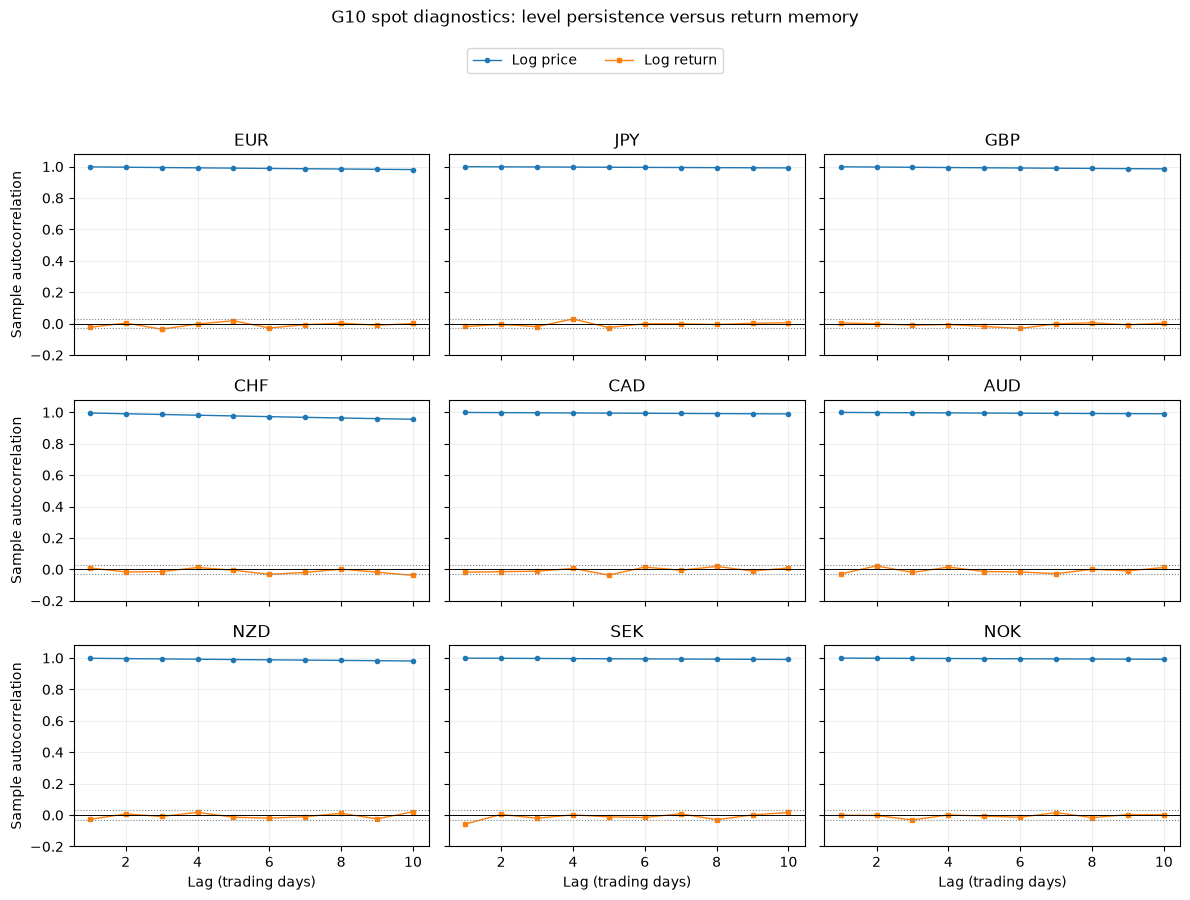

At the 5% ADF level, the log-price unit-root null is rejected for **CHF**; the return unit-root null is rejected for **EUR, JPY, GBP, CHF, CAD, AUD, NZD, SEK, NOK**. **SEK** has the largest absolute short-lag return autocorrelation (0.057). Thus any exception should be read alongside both the level and return diagnostics. CHF is the level-test exception here; its history includes the 2015 end of the franc/euro floor, although this test alone cannot attribute the result to that regime change. USD/USD is constant by construction and cannot be diagnosed as a stochastic random walk.

In [5]:
import matplotlib.pyplot as plt
import warnings
from scipy import stats
from statsmodels.tsa.stattools import acf, adfuller, pacf

diagnostic_spot = spot_usd.loc[carry_pnl.index, FOREIGN].copy()
log_spot = np.log(diagnostic_spot)
spot_returns = log_spot.diff().dropna()
rw_rows = []
rw_acf = {}
for currency in FOREIGN:
    price = log_spot[currency].dropna()
    ret = spot_returns[currency].dropna()
    price_acf = acf(price, nlags=10, fft=True)
    return_acf = acf(ret, nlags=10, fft=True)
    rw_acf[currency] = (price_acf, return_acf)
    price_adf_p = adfuller(price, regression="c", maxlag=10,
                           autolag="AIC", result_object=False)[1]
    return_adf_p = adfuller(ret, regression="c", maxlag=10,
                            autolag="AIC", result_object=False)[1]
    rw_rows.append({
        "currency": currency,
        "log-price ACF(1)": price_acf[1],
        "return ACF(1)": return_acf[1],
        "largest |return ACF|, lags 1–10": np.max(np.abs(return_acf[1:])),
        "ADF price p": price_adf_p,
        "ADF return p": return_adf_p,
    })
rw_summary = pd.DataFrame(rw_rows).set_index("currency")
rw_summary.loc["USD", :] = np.nan
rw_summary = rw_summary.reindex(CURRENCIES)
rw_summary["spot status"] = "market quote"
rw_summary.loc["USD", "spot status"] = "deterministic numeraire"
display(rw_summary.round(4))

fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
lags = np.arange(1, 11)
for ax, currency in zip(axes.flat, FOREIGN):
    price_acf, return_acf = rw_acf[currency]
    ax.plot(lags, price_acf[1:], "o-", ms=3, lw=1, label="Log price")
    ax.plot(lags, return_acf[1:], "s-", ms=3, lw=1, label="Log return")
    ax.axhline(0, color="black", lw=.7)
    ax.axhline(1.96 / np.sqrt(len(spot_returns)), color="gray", ls=":", lw=.8)
    ax.axhline(-1.96 / np.sqrt(len(spot_returns)), color="gray", ls=":", lw=.8)
    ax.set_title(currency)
    ax.set_ylim(-.2, 1.08)
    ax.grid(alpha=.2)
for ax in axes[-1, :]:
    ax.set_xlabel("Lag (trading days)")
for ax in axes[:, 0]:
    ax.set_ylabel("Sample autocorrelation")
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center", bbox_to_anchor=(.5, .96), ncol=2)
fig.suptitle("G10 spot diagnostics: level persistence versus return memory", y=.995)
fig.tight_layout(rect=(0, 0, 1, .91))
plt.show()

price_rejections = rw_summary.index[(rw_summary["ADF price p"] < .05).fillna(False)].tolist()
return_rejections = rw_summary.index[(rw_summary["ADF return p"] < .05).fillna(False)].tolist()
largest_return_acf = rw_summary.loc[FOREIGN, "largest |return ACF|, lags 1–10"].idxmax()
display(Markdown(
    f"At the 5% ADF level, the log-price unit-root null is rejected for "
    f"**{', '.join(price_rejections) if price_rejections else 'none of the nine traded currencies'}**; "
    f"the return unit-root null is rejected for "
    f"**{', '.join(return_rejections) if return_rejections else 'none'}**. "
    f"**{largest_return_acf}** has the largest absolute short-lag return autocorrelation "
    f"({rw_summary.loc[largest_return_acf, 'largest |return ACF|, lags 1–10']:.3f}). "
    "Thus any exception should be read alongside both the level and return diagnostics. "
    + ("CHF is the level-test exception here; its history includes the 2015 end of the franc/euro floor, "
       "although this test alone cannot attribute the result to that regime change. "
       if "CHF" in price_rejections else "")
    +
    "USD/USD is constant by construction and cannot be diagnosed as a stochastic random walk."
))


### 2.2 — Is average carry positive?

The lecture's IID mean test uses $t=\bar r/(s/\sqrt n)$ and a two-sided 5% threshold. The series are daily P&L in **percentage points**, so the mean and standard error below are converted to **basis points per day**. These p-values are descriptive: volatility clustering and testing nine currencies can make nominal significance look stronger than a robust strategy result. The bootstrap next revisits selected legs.


In [6]:
rate_spread_annual_pct = rates_at_start[FOREIGN].sub(rates_at_start["USD"], axis=0).loc[carry_pnl.index]
mean_rows = []
for currency in FOREIGN:
    sample = carry_pnl[currency].dropna()
    n = len(sample)
    mean_pct = sample.mean()
    se_pct = sample.std(ddof=1) / np.sqrt(n)
    t_stat = mean_pct / se_pct
    p_two_sided = 2 * stats.t.sf(abs(t_stat), df=n - 1)
    mean_rows.append({
        "currency": currency,
        "n days": n,
        "mean daily P&L (bp)": mean_pct * 100,
        "SE (bp)": se_pct * 100,
        "t statistic": t_stat,
        "two-sided p": p_two_sided,
        "mean rate spread (annual %pt)": rate_spread_annual_pct[currency].mean(),
        "annualized mean P&L (%)": mean_pct * 252,
    })
mean_test_summary = pd.DataFrame(mean_rows).set_index("currency")
mean_test_summary["positive at 5%?"] = (
    (mean_test_summary["mean daily P&L (bp)"] > 0)
    & (mean_test_summary["two-sided p"] < .05)
)
display(mean_test_summary.sort_values("mean rate spread (annual %pt)", ascending=False).round(4))

positive_carry = mean_test_summary.index[mean_test_summary["positive at 5%?"]].tolist()
not_positive = [c for c in FOREIGN if c not in positive_carry]
negative_significant = mean_test_summary.index[
    (mean_test_summary["mean daily P&L (bp)"] < 0)
    & (mean_test_summary["two-sided p"] < .05)
].tolist()
rank_corr = stats.spearmanr(
    mean_test_summary["mean rate spread (annual %pt)"],
    mean_test_summary["annualized mean P&L (%)"],
).statistic
highest_yield = mean_test_summary["mean rate spread (annual %pt)"].idxmax()
highest_pnl = mean_test_summary["annualized mean P&L (%)"].idxmax()
display(Markdown(
    f"By this IID two-sided test, **{', '.join(positive_carry) if positive_carry else 'none'}** "
    f"show significant positive mean carry; **{', '.join(not_positive) if not_positive else 'none'}** "
    f"do not. Significant *negative* mean carry appears for "
    f"**{', '.join(negative_significant) if negative_significant else 'none'}**. "
    "The cross-currency Spearman rank correlation between average quoted "
    f"rate differential and realized average P&L is **{rank_corr:.2f}**. "
    f"The highest average yield spread belongs to **{highest_yield}**, while the "
    f"highest realized mean P&L belongs to **{highest_pnl}**. "
    "This is a direct check on whether higher-yield currencies also deliver more carry; "
    "the spot component can overwhelm the interest differential even when UIP fails on average."
))


,n days,mean daily P&L (bp),SE (bp),t statistic,two-sided p,mean rate spread (annual %pt),annualized mean P&L (%),positive at 5%?
currency,,,,,,,,
NZD,4295,-0.0423,1.0387,-0.0407,0.9675,1.2100,-0.1065,False
AUD,4295,-0.1891,1.0069,-0.1878,0.8510,1.0539,-0.4766,False
NOK,4295,-1.0094,1.1233,-0.8986,0.3689,0.2835,-2.5437,False
CAD,4295,-0.6995,0.6981,-1.0020,0.3164,0.0489,-1.7626,False
GBP,4295,-0.3417,0.8354,-0.4091,0.6825,-0.1412,-0.8612,False
SEK,4295,-1.0449,1.0500,-0.9952,0.3197,-0.7214,-2.6331,False
EUR,4295,-0.7865,0.8073,-0.9742,0.3300,-0.9736,-1.9820,False
JPY,4295,-1.8609,0.8838,-2.1055,0.0353,-1.4159,-4.6895,False
CHF,4295,-0.0276,0.9433,-0.0293,0.9766,-1.6450,-0.0697,False


By this IID two-sided test, **none** show significant positive mean carry; **EUR, JPY, GBP, CHF, CAD, AUD, NZD, SEK, NOK** do not. Significant *negative* mean carry appears for **JPY**. The cross-currency Spearman rank correlation between average quoted rate differential and realized average P&L is **0.25**. The highest average yield spread belongs to **NZD**, while the highest realized mean P&L belongs to **CHF**. This is a direct check on whether higher-yield currencies also deliver more carry; the spot component can overwhelm the interest differential even when UIP fails on average.

### 2.3 — Bootstrap the lecture pair and two cross-sectional contrasts

Long AUD/short JPY is reconstructed as the **AUD/USD long carry minus JPY/USD long carry** on identical dates. USD spot changes and USD funding then cancel algebraically, leaving AUD/JPY spot P&L plus the AUD-minus-JPY accrued differential. I use 1,000 IID day resamples with a fixed seed, as requested. The bootstrap interval measures sensitivity to which days appear in this sample; it does not preserve volatility clusters or establish out-of-sample profitability.


,sample mean (bp/day),bootstrap 95% low (bp/day),bootstrap 95% high (bp/day),share of resamples > 0
trade,,,,
AUD/JPY,1.6718,-0.5345,4.0507,0.924
NZD/USD,-0.0423,-2.0478,1.9699,0.478
CHF/USD,-0.0276,-1.9069,1.7247,0.475


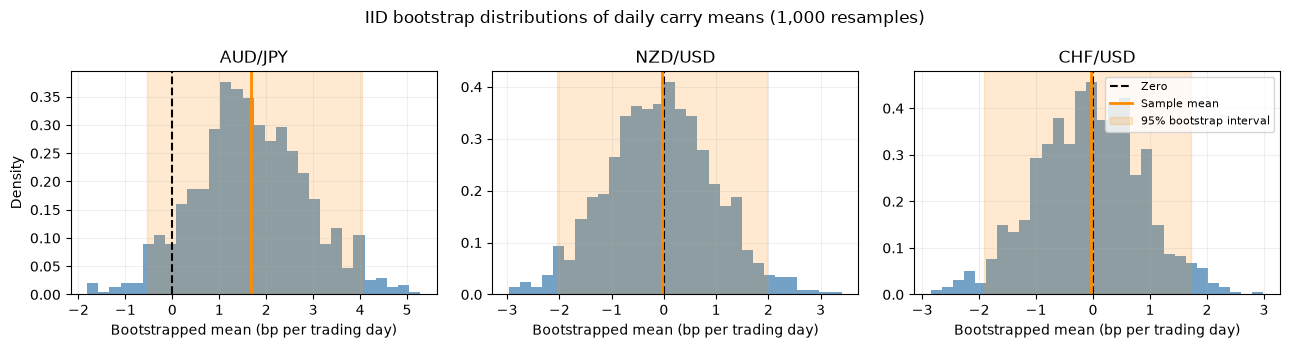

For the lecture's AUD/JPY trade, the sample mean is **1.672 bp/day** and the IID bootstrap 95% interval is **[-0.534, 4.051] bp/day**. The interval includes zero, so the lecture pair's positive-mean claim is fragile under this resampling check. The interval cannot rule out regime shifts or clustered crash losses.

In [7]:
aud_jpy_pnl = (carry_pnl["AUD"] - carry_pnl["JPY"]).rename("AUD/JPY")
high_spread_currency = mean_test_summary["mean rate spread (annual %pt)"].idxmax()
low_spread_currency = mean_test_summary["mean rate spread (annual %pt)"].idxmin()
bootstrap_samples = {
    "AUD/JPY": aud_jpy_pnl,
    f"{high_spread_currency}/USD": carry_pnl[high_spread_currency],
    f"{low_spread_currency}/USD": carry_pnl[low_spread_currency],
}
# If AUD or JPY is an extreme, AUD/JPY remains a distinct cross-currency trade.
rng = np.random.default_rng(20260930)
boot_means = {}
bootstrap_rows = []
for name, series in bootstrap_samples.items():
    values_bp = series.dropna().to_numpy(dtype=float) * 100
    draws = np.array([rng.choice(values_bp, size=len(values_bp), replace=True).mean()
                      for _ in range(1000)])
    boot_means[name] = draws
    lo, hi = np.quantile(draws, [.025, .975])
    bootstrap_rows.append({
        "trade": name,
        "sample mean (bp/day)": values_bp.mean(),
        "bootstrap 95% low (bp/day)": lo,
        "bootstrap 95% high (bp/day)": hi,
        "share of resamples > 0": (draws > 0).mean(),
    })
bootstrap_summary = pd.DataFrame(bootstrap_rows).set_index("trade")
display(bootstrap_summary.round(4))

fig, axes = plt.subplots(1, len(boot_means), figsize=(13, 3.5))
for ax, (name, draws) in zip(np.atleast_1d(axes), boot_means.items()):
    row = bootstrap_summary.loc[name]
    ax.hist(draws, bins=30, density=True, color="steelblue", alpha=.75)
    ax.axvline(0, color="black", ls="--", label="Zero")
    ax.axvline(row["sample mean (bp/day)"], color="darkorange", lw=2, label="Sample mean")
    ax.axvspan(row["bootstrap 95% low (bp/day)"], row["bootstrap 95% high (bp/day)"],
               color="darkorange", alpha=.18, label="95% bootstrap interval")
    ax.set_title(name)
    ax.set_xlabel("Bootstrapped mean (bp per trading day)")
    ax.grid(alpha=.2)
axes[0].set_ylabel("Density")
axes[-1].legend(fontsize=8)
fig.suptitle("IID bootstrap distributions of daily carry means (1,000 resamples)")
fig.tight_layout()
plt.show()

aud_boot = bootstrap_summary.loc["AUD/JPY"]
if aud_boot["bootstrap 95% low (bp/day)"] > 0:
    aud_boot_conclusion = "The interval is entirely positive, so its positive sample mean survives this day-resampling check. "
elif aud_boot["bootstrap 95% high (bp/day)"] < 0:
    aud_boot_conclusion = "The interval is entirely negative, contradicting a positive-mean claim for this sample. "
else:
    aud_boot_conclusion = "The interval includes zero, so the lecture pair's positive-mean claim is fragile under this resampling check. "
display(Markdown(
    f"For the lecture's AUD/JPY trade, the sample mean is "
    f"**{aud_boot['sample mean (bp/day)']:.3f} bp/day** and the IID bootstrap "
    f"95% interval is **[{aud_boot['bootstrap 95% low (bp/day)']:.3f}, "
    f"{aud_boot['bootstrap 95% high (bp/day)']:.3f}] bp/day**. "
    + aud_boot_conclusion
    + "The interval cannot rule out regime shifts or clustered crash losses."
))


#### Saved Section 2 discussion — data as of 2026-09-30

The nine traded log spot levels look highly persistent. CHF is the only level series for which the ADF test rejects a unit root at 5% (**p = 0.030**); the other eight do not. All nine return series reject a unit root, and even the largest absolute short-lag return autocorrelation, SEK's **0.057**, is small. USD/USD is a deterministic numeraire, so no unit-root test applies to it.

The IID mean tests find **no significantly positive** USD-funded carry leg at 5%; JPY has a significantly *negative* mean (**p = 0.035**). Average rate spread and realized carry mean have only a **0.25** Spearman rank correlation across currencies: NZD has the highest average spread, yet CHF has the highest (still slightly negative) realized mean. The AUD/JPY trade averages **1.672 bp per day**, but its 1,000-resample IID bootstrap 95% interval is **[−0.534, 4.051] bp per day**. That interval crosses zero, so the apparent positive single-pair mean is fragile; an IID bootstrap also cannot reproduce clustered crash episodes.


## Section 3 — Mean structure, volatility, and UIP across the basket

The ARMA comparison uses the most recent **1,250 common daily observations** (about five years) so the bounded grid remains practical to rerun and focuses on a coherent recent regime. The GARCH fits use the full aligned carry sample, where more tail observations help estimate volatility. These are explanatory full-sample models; Section 5 must refit using only history available at each rebalance before using forecasts to trade.


### 3.1 — ARMA identification

The ACF/PACF figure shows lags 1–10 for each daily carry series. I compare ARMA(0,0), (1,0), (0,1), (1,1), (2,0), and (0,2) with a constant, choosing the **lowest BIC**. The BIC improvement over white noise is evidence of mean structure, but a small improvement or a nonzero order alone is not evidence of useful out-of-sample predictability.


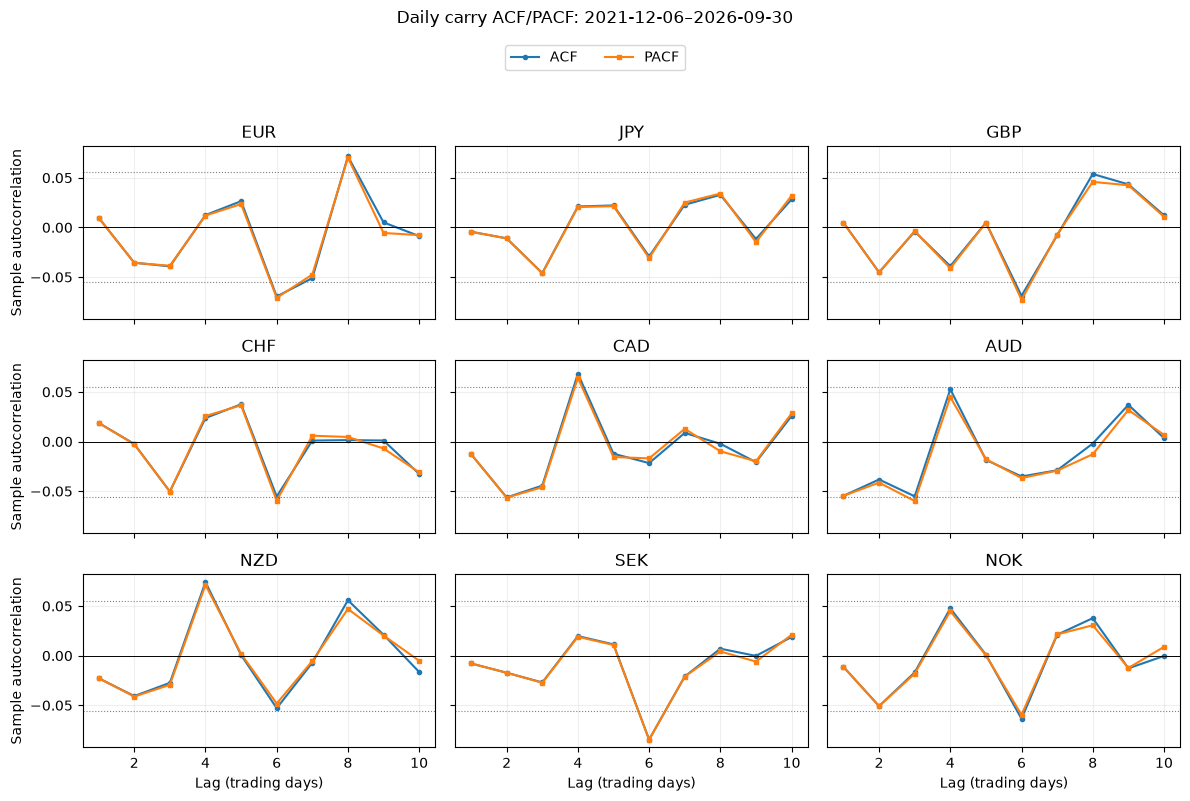

,"best ARMA(p,q) by BIC",best BIC,"BIC gain vs (0,0)",clear mean structure?
currency,,,,
EUR,"(0,0)",1714.15,0.0,False
JPY,"(0,0)",2399.85,0.0,False
GBP,"(0,0)",1985.61,0.0,False
CHF,"(0,0)",1885.98,0.0,False
CAD,"(0,0)",1130.88,0.0,False
AUD,"(0,0)",2502.08,0.0,False
NZD,"(0,0)",2480.17,0.0,False
SEK,"(0,0)",2664.46,0.0,False
NOK,"(0,0)",2805.90,0.0,False


On the common recent sample, **no currency** has a BIC improvement of at least 10 over a constant-mean white-noise model. This threshold identifies statistical outliers in the basket; even for them, an in-sample ARMA gain must survive walk-forward testing before it can be called exploitable.

In [8]:
from statsmodels.tsa.arima.model import ARIMA

ARMA_MAX_OBS = 1250
arma_sample = carry_pnl.tail(ARMA_MAX_OBS)
arma_orders = [(0, 0), (1, 0), (0, 1), (1, 1), (2, 0), (0, 2)]

fig, axes = plt.subplots(3, 3, figsize=(12, 8), sharex=True, sharey=True)
for ax, currency in zip(axes.flat, FOREIGN):
    y = arma_sample[currency].dropna().to_numpy()
    acf_vals = acf(y, nlags=10, fft=True)[1:]
    pacf_vals = pacf(y, nlags=10, method="ywm")[1:]
    ax.plot(range(1, 11), acf_vals, "o-", ms=3, label="ACF")
    ax.plot(range(1, 11), pacf_vals, "s-", ms=3, label="PACF")
    band = 1.96 / np.sqrt(len(y))
    ax.axhline(0, color="black", lw=.7)
    ax.axhline(band, color="gray", ls=":", lw=.8)
    ax.axhline(-band, color="gray", ls=":", lw=.8)
    ax.set_title(currency)
    ax.grid(alpha=.2)
for ax in axes[-1, :]:
    ax.set_xlabel("Lag (trading days)")
for ax in axes[:, 0]:
    ax.set_ylabel("Sample autocorrelation")
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center", bbox_to_anchor=(.5, .96), ncol=2)
fig.suptitle(f"Daily carry ACF/PACF: {arma_sample.index.min().date()}–{arma_sample.index.max().date()}", y=.995)
fig.tight_layout(rect=(0, 0, 1, .91))
plt.show()

def fit_arma_grid(series, orders=arma_orders):
    results = {}
    y = series.dropna().to_numpy(dtype=float)
    for p, q in orders:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                fit = ARIMA(y, order=(p, 0, q), trend="c").fit(
                    method_kwargs={"maxiter": 50}
                )
            if np.isfinite(fit.bic):
                results[(p, q)] = fit
        except (ValueError, np.linalg.LinAlgError):
            continue
    if (0, 0) not in results:
        raise RuntimeError("ARMA white-noise baseline failed to fit")
    best_order = min(results, key=lambda order: results[order].bic)
    return best_order, results

arma_fits = {}
arma_rows = []
for currency in FOREIGN:
    best_order, candidate_fits = fit_arma_grid(arma_sample[currency])
    arma_fits[currency] = candidate_fits[best_order]
    bic_gain = candidate_fits[(0, 0)].bic - candidate_fits[best_order].bic
    arma_rows.append({
        "currency": currency,
        "best ARMA(p,q) by BIC": f"({best_order[0]},{best_order[1]})",
        "best BIC": candidate_fits[best_order].bic,
        "BIC gain vs (0,0)": bic_gain,
        "clear mean structure?": best_order != (0, 0) and bic_gain >= 10,
    })
arma_summary = pd.DataFrame(arma_rows).set_index("currency")
display(arma_summary.round(2))
mean_outliers = arma_summary.index[arma_summary["clear mean structure?"]].tolist()
display(Markdown(
    f"On the common recent sample, **{', '.join(mean_outliers) if mean_outliers else 'no currency'}** "
    "has a BIC improvement of at least 10 over a constant-mean white-noise model. "
    "This threshold identifies statistical outliers in the basket; even for them, "
    "an in-sample ARMA gain must survive walk-forward testing before it can be called exploitable."
))


### 3.2 — GARCH(1,1) for each currency

I fit Normal and Student-$t$ innovations to each full-sample daily carry series. The table reports parameters from the **AIC-winning** fit and shows both AIC and BIC distribution choices. Persistence is $\hat\alpha_1+\hat\beta_1$. Ljung–Box p-values at 10 lags assess remaining autocorrelation in standardized residuals and their squares; an ARCH-LM p-value on demeaned raw P&L gives a direct preliminary test of volatility clustering. A high persistence estimate does not mean the unconditional volatility is constant, nor does a small Ljung–Box p-value validate a model.


In [9]:
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

garch_fits = {}                 # AIC-winning fitted results, one per currency.
garch_candidates = {}           # Both Normal and Student-t results per currency.
garch_rows = []
for currency in FOREIGN:
    y = carry_pnl[currency].dropna().to_numpy(dtype=float)
    candidates = {}
    for distribution in ("normal", "t"):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit = arch_model(y, mean="Constant", vol="GARCH", p=1, q=1,
                             dist=distribution, rescale=False).fit(disp="off")
        if not np.isfinite(fit.aic):
            raise RuntimeError(f"Non-finite GARCH likelihood for {currency} ({distribution})")
        candidates[distribution] = fit
    garch_candidates[currency] = candidates
    aic_winner = min(candidates, key=lambda dist: candidates[dist].aic)
    bic_winner = min(candidates, key=lambda dist: candidates[dist].bic)
    best = candidates[aic_winner]
    garch_fits[currency] = best
    z = np.asarray(best.std_resid, dtype=float)
    z = z[np.isfinite(z)]
    lb_p = acorr_ljungbox(z, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
    lb_sq_p = acorr_ljungbox(z ** 2, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        arch_p = het_arch(y - y.mean(), nlags=10)[1]
    alpha = best.params["alpha[1]"]
    beta = best.params["beta[1]"]
    garch_rows.append({
        "currency": currency,
        "alpha1": alpha,
        "beta1": beta,
        "persistence": alpha + beta,
        "AIC winner": "Student-t" if aic_winner == "t" else "Normal",
        "BIC winner": "Student-t" if bic_winner == "t" else "Normal",
        "AIC normal": candidates["normal"].aic,
        "AIC t": candidates["t"].aic,
        "LB residual p (10)": lb_p,
        "LB squared p (10)": lb_sq_p,
        "ARCH-LM p (10)": arch_p,
    })
garch_summary = pd.DataFrame(garch_rows).set_index("currency")
display(garch_summary.round(4))

clustered = garch_summary.index[garch_summary["ARCH-LM p (10)"] < .05].tolist()
strongest = garch_summary["persistence"].idxmax()
weakest = garch_summary["persistence"].idxmin()
leftover_vol = garch_summary.index[garch_summary["LB squared p (10)"] < .05].tolist()
t_aic_count = (garch_summary["AIC winner"] == "Student-t").sum()
display(Markdown(
    f"The raw-return ARCH-LM test detects clustering at 5% in "
    f"**{', '.join(clustered) if clustered else 'none'}**. Estimated GARCH "
    f"persistence is highest in **{strongest}** "
    f"({garch_summary.loc[strongest, 'persistence']:.3f}) and lowest in **{weakest}** "
    f"({garch_summary.loc[weakest, 'persistence']:.3f}). "
    f"Squared standardized residuals still reject no autocorrelation for "
    f"**{', '.join(leftover_vol) if leftover_vol else 'none'}**, pointing to "
    "remaining volatility structure if any. These relative estimates show why "
    "equal notional across all legs is not equal risk. "
    f"Student-$t$ innovations win AIC in **{t_aic_count} of {len(FOREIGN)}** fits, "
    "consistent with heavier tails than a Normal shock model."
))


,alpha1,beta1,persistence,AIC winner,BIC winner,AIC normal,AIC t,LB residual p (10),LB squared p (10),ARCH-LM p (10)
currency,,,,,,,,,,
EUR,0.0364,0.9612,0.9976,Student-t,Student-t,6100.2209,5923.9686,0.2197,0.3950,0.0000
JPY,0.0708,0.9214,0.9922,Student-t,Student-t,6971.1466,6575.1376,0.7985,0.7682,0.0000
GBP,0.0395,0.9497,0.9892,Student-t,Student-t,6492.5015,6265.3400,0.9339,0.0390,0.0000
CHF,0.0329,0.9535,0.9864,Student-t,Student-t,7410.7951,6243.0869,0.3828,1.0000,0.8997
CAD,0.0415,0.9541,0.9955,Student-t,Student-t,4885.2049,4792.9238,0.9746,0.7997,0.0000
AUD,0.0464,0.9435,0.9900,Student-t,Student-t,8121.9780,8019.2993,0.6945,0.4927,0.0000
NZD,0.0387,0.9510,0.9897,Student-t,Student-t,8500.1485,8435.2228,0.6938,0.1468,0.0000
SEK,0.0347,0.9589,0.9937,Student-t,Student-t,8593.6164,8491.5830,0.0700,0.0505,0.0000
NOK,0.0382,0.9575,0.9957,Student-t,Student-t,9047.9857,8913.7901,0.6937,0.0071,0.0000


The raw-return ARCH-LM test detects clustering at 5% in **EUR, JPY, GBP, CAD, AUD, NZD, SEK, NOK**. Estimated GARCH persistence is highest in **EUR** (0.998) and lowest in **CHF** (0.986). Squared standardized residuals still reject no autocorrelation for **GBP, NOK**, pointing to remaining volatility structure if any. These relative estimates show why equal notional across all legs is not equal risk. Student-$t$ innovations win AIC in **9 of 9** fits, consistent with heavier tails than a Normal shock model.

### 3.3 — Fama/UIP regression across the basket

There is a quote-direction subtlety. Section 1 defines $S$ as **USD per foreign unit** for long-currency P&L. The prompt's stated UIP null $\beta=1$ instead corresponds to $s=\log(\text{foreign units per USD})=-\log S$: a high foreign rate predicts foreign-currency depreciation, so $\Delta s$ should be positive. I therefore regress the *next month's* change in this inverse log quote on the **foreign-minus-USD interest differential accrued over that month's actual calendar-day span**. Both sides are in percentage points, making the UIP benchmark $\beta=1$. The rate at month-end $t$ is drawn from the conservatively publication-lagged Section 1 series; the spot change begins only after $t$. Standard errors are HAC with three monthly lags. A coefficient below one means the expected depreciation falls short of the quoted interest advantage, which supports positive gross long-foreign carry for positive spreads; it does not by itself guarantee a profitable cost-adjusted basket.


In [10]:
import statsmodels.api as sm

# Retain the actual date of each month's final common FX observation.
month_end_spot = spot_usd.loc[carry_pnl.index, FOREIGN].groupby(
    spot_usd.loc[carry_pnl.index].index.to_period("M")
).tail(1)
month_end_rates = rates_known.reindex(month_end_spot.index, method="ffill")
next_days = (month_end_spot.index.to_series().shift(-1) -
             month_end_spot.index.to_series()).dt.days
monthly_foreign_accrual = accrued_pct(month_end_rates[FOREIGN], next_days)
monthly_usd_accrual = accrued_pct(month_end_rates["USD"], next_days)
monthly_spread = monthly_foreign_accrual.sub(monthly_usd_accrual, axis=0)
next_inverse_spot_change = -100 * (np.log(month_end_spot).shift(-1) - np.log(month_end_spot))

fama_models = {}
fama_rows = []
for currency in FOREIGN:
    reg_data = pd.DataFrame({
        "next inverse spot change (%)": next_inverse_spot_change[currency],
        "accrued foreign-minus-USD spread (%)": monthly_spread[currency],
    }).dropna()
    if len(reg_data) < 36 or reg_data.iloc[:, 1].std() == 0:
        raise RuntimeError(f"Insufficient variation for {currency} monthly Fama regression")
    explanatory = sm.add_constant(reg_data.iloc[:, 1], has_constant="add")
    model = sm.OLS(reg_data.iloc[:, 0], explanatory).fit(
        cov_type="HAC", cov_kwds={"maxlags": 3}
    )
    fama_models[currency] = model
    beta = model.params.iloc[1]
    se = model.bse.iloc[1]
    fama_rows.append({
        "currency": currency,
        "months": len(reg_data),
        "beta": beta,
        "HAC SE": se,
        "95% CI low": beta - 1.96 * se,
        "95% CI high": beta + 1.96 * se,
        "below UIP β=1 at 5%?": beta + 1.96 * se < 1,
        "R-squared": model.rsquared,
    })
fama_summary = pd.DataFrame(fama_rows).set_index("currency")
display(fama_summary.round(3))

below_one = fama_summary.index[fama_summary["beta"] < 1].tolist()
below_zero = fama_summary.index[fama_summary["beta"] < 0].tolist()
reject_uip_below = fama_summary.index[fama_summary["below UIP β=1 at 5%?"]].tolist()
if reject_uip_below:
    fama_basket_read = (
        "Those statistically below one provide pair-specific evidence that foreign-currency "
        "depreciation has failed to offset the rate advantage fully. They motivate testing a "
        "cross-sectional carry basket, though returns and costs remain decisive."
    )
else:
    fama_basket_read = (
        "None has a 95% upper bound below one, so these regressions do **not** establish "
        "a basket-wide forward-premium puzzle. Section 4 is an exploratory carry backtest, "
        "and any allocation case must rest on its realized, cost-adjusted results."
    )
display(Markdown(
    f"Point estimates are below UIP's **β=1** for **{', '.join(below_one) if below_one else 'none'}** "
    f"and negative for **{', '.join(below_zero) if below_zero else 'none'}**. "
    f"The upper 95% confidence bound is below one for "
    f"**{', '.join(reject_uip_below) if reject_uip_below else 'none'}**. "
    "A point estimate below one alone is weak evidence when its confidence interval is wide. "
    + fama_basket_read
))


,months,beta,HAC SE,95% CI low,95% CI high,below UIP β=1 at 5%?,R-squared
currency,,,,,,,
EUR,198,2.021,2.038,-1.974,6.015,False,0.004
JPY,198,0.210,1.403,-2.540,2.959,False,0.000
GBP,198,1.840,3.508,-5.035,8.715,False,0.001
CHF,198,0.347,1.533,-2.657,3.351,False,0.000
CAD,198,2.210,2.126,-1.956,6.376,False,0.004
AUD,198,-0.308,1.429,-3.110,2.493,False,0.000
NZD,198,0.097,1.743,-3.320,3.514,False,0.000
SEK,198,0.432,1.750,-2.998,3.862,False,0.000
NOK,198,0.561,2.162,-3.677,4.798,False,0.000


Point estimates are below UIP's **β=1** for **JPY, CHF, AUD, NZD, SEK, NOK** and negative for **AUD**. The upper 95% confidence bound is below one for **none**. A point estimate below one alone is weak evidence when its confidence interval is wide. None has a 95% upper bound below one, so these regressions do **not** establish a basket-wide forward-premium puzzle. Section 4 is an exploratory carry backtest, and any allocation case must rest on its realized, cost-adjusted results.

#### Saved Section 3 discussion — data as of 2026-09-30

On the recent 1,250-observation comparison window, **ARMA(0,0)** has the best BIC for all nine carry series. The full-sample GARCH fits tell a different story about variance: Student-t innovations win AIC and BIC for every currency, and estimated volatility persistence ranges from **0.986 for CHF** to **0.998 for EUR**. Squared standardized residuals still show a Ljung–Box signal for GBP and NOK, so a GARCH(1,1) fit does not capture every feature of their volatility.

The monthly Fama estimates are imprecise. AUD's point estimate is **−0.308**, but its HAC 95% interval is **[−3.110, 2.493]**; no currency's interval excludes the UIP benchmark of beta = 1 on the low side. These regressions do **not** establish a basket-wide forward-premium puzzle. The portfolio test that follows is therefore exploratory and must stand on its out-of-sample timing and net results, rather than an asserted universal anomaly.


## Section 4 — Building the G10 Carry Basket

### 4.1 Rank-and-sort basket

I rebalance **after the last common FX close of each month**, so the resulting positions first earn the return on the next common FX observation (the first one of the next month). The rank signal uses the Section 1 rates *known by that close*: a monthly observation has already been delayed by two months. At each rebalance I buy the three highest foreign-minus-USD rates and short the three lowest. Equal weights are +1/6 and −1/6, giving 50% long notional, 50% short notional, and 100% gross exposure.

### 4.2 Volatility-targeted basket

The risk-parity version retains the same selected currencies and normalizes inverse **one-step-ahead GARCH-t forecast volatility** separately within the long and short books to 50% per side.

The GARCH fits in Section 3 are descriptive full-sample estimates; using them directly to size earlier trades would leak future information. The live backtest below instead starts after 504 common observations, refits GARCH(1,1)-Student-t models on at most the trailing 756 observations **quarterly**, and updates their variance forecasts with each newly observed return. Quarterly parameter refreshes are a practical compromise: volatility responds daily through the GARCH recursion, while its slower-moving parameters need not be re-estimated daily. Every forecast used for the next holding period depends only on data through the previous close. The correlation estimate used for portfolio VaR similarly uses only the trailing 252 observed days.

Daily P&L is the weight times each Section 1 carry P&L, in percentage points. Within a month weights are held fixed; there is no day-by-day rebalancing back to target weights. This is a constant-notional approximation rather than a fully self-financing mark-to-market portfolio.

In [11]:
import warnings
import matplotlib.pyplot as plt
from scipy import stats
from arch import arch_model


def _fit_garch_t(history_pct):
    # Fit one currency using only observations available at the signal close.
    model = arch_model(
        history_pct.to_numpy(dtype=float), mean="Constant", vol="GARCH",
        p=1, q=1, dist="StudentsT", rescale=False,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = model.fit(disp="off", show_warning=False, options={"maxiter": 250})
    if fit.convergence_flag != 0:
        raise RuntimeError(f"GARCH-t optimizer returned flag {fit.convergence_flag}")
    par = fit.params
    next_variance = float(fit.forecast(horizon=1, reindex=False).variance.iloc[-1, 0])
    if not np.isfinite(next_variance) or next_variance <= 0:
        raise RuntimeError("Non-positive one-step GARCH variance")
    return {
        "mu": float(par["mu"]), "omega": float(par["omega"]),
        "alpha": float(par["alpha[1]"]), "beta": float(par["beta[1]"]),
        "nu": float(par["nu"]), "next_variance": next_variance,
    }


def _inverse_vol_weights(high, low, next_variance, currencies):
    out = pd.Series(0.0, index=currencies)
    high_inv = 1.0 / np.sqrt(next_variance[high])
    low_inv = 1.0 / np.sqrt(next_variance[low])
    out.loc[high] = 0.5 * high_inv / high_inv.sum()
    out.loc[low] = -0.5 * low_inv / low_inv.sum()
    return out


def walk_forward_g10(carry, rate_data, min_history=504, fit_window=756):
    # A signal at index i sets weights/VaR for i+1, never for i.
    # Refit failures reuse only previously known parameters and are logged.
    carry = carry[FOREIGN].sort_index().dropna(how="any")
    dates = carry.index
    if len(carry) < min_history + 30:
        raise ValueError("Insufficient common history for a walk-forward test")
    # Section 1 applied its two-month release lag to rates_known already.
    known = rate_data.reindex(dates, method="ffill")[CURRENCIES]
    differentials = known[FOREIGN].sub(known["USD"], axis=0)
    if differentials.isna().any().any():
        raise ValueError("Missing as-of rate differential in the common sample")

    w_equal = pd.DataFrame(0.0, index=dates, columns=FOREIGN)
    w_vol = pd.DataFrame(0.0, index=dates, columns=FOREIGN)
    var95 = pd.Series(np.nan, index=dates, name="ex_ante_95pct_VaR_pct")
    sigma_forecast = pd.Series(np.nan, index=dates, name="ex_ante_vol_pct")
    active_equal = pd.Series(0.0, index=FOREIGN)
    active_vol = pd.Series(0.0, index=FOREIGN)
    parameters = {}
    next_var = pd.Series(np.nan, index=FOREIGN)
    refits, failures, rebalances = [], [], []

    for i in range(len(dates) - 1):
        # At this close y_i has just been observed. The recursion yields the
        # variance of y_(i+1), from parameters estimated in earlier closes.
        if parameters:
            for c in FOREIGN:
                p = parameters[c]
                residual = float(carry.iloc[i][c] - p["mu"])
                next_var[c] = max(
                    p["omega"] + p["alpha"] * residual**2 +
                    p["beta"] * float(next_var[c]), 1e-10,
                )

        is_month_end = dates[i].to_period("M") != dates[i + 1].to_period("M")
        if is_month_end and i + 1 >= min_history:
            trade_month = dates[i + 1].to_period("M")
            must_refit = not parameters or trade_month.month in (1, 4, 7, 10)
            if must_refit:
                history = carry.iloc[max(0, i + 1 - fit_window):i + 1]
                for c in FOREIGN:
                    try:
                        fit_info = _fit_garch_t(history[c])
                        parameters[c] = fit_info
                        next_var[c] = fit_info["next_variance"]
                        refits.append((dates[i], c, len(history)))
                    except Exception as exc:
                        if c not in parameters:
                            raise RuntimeError(
                                f"Initial GARCH-t fit failed for {c} on {dates[i].date()}"
                            ) from exc
                        failures.append((dates[i], c, str(exc)))
            if not parameters:
                raise RuntimeError("No GARCH models available at first rebalance")
            ranks = differentials.iloc[i].sort_values()
            low = list(ranks.index[:3])
            high = list(ranks.index[-3:])
            active_equal = pd.Series(0.0, index=FOREIGN)
            active_equal.loc[high] = 1.0 / 6.0
            active_equal.loc[low] = -1.0 / 6.0
            active_vol = _inverse_vol_weights(high, low, next_var, FOREIGN)
            rebalances.append({
                "signal_close": dates[i], "first_holding_day": dates[i + 1],
                "long": ", ".join(high), "short": ", ".join(low),
                "top_rate_spread_pp": float(ranks.iloc[-1]),
                "bottom_rate_spread_pp": float(ranks.iloc[0]),
            })

        # Both the position and the risk forecast stamped on i+1 were set at
        # the close of i, before the return at i+1 exists.
        w_equal.iloc[i + 1] = active_equal
        w_vol.iloc[i + 1] = active_vol
        if active_vol.abs().sum() > 0:
            risk_history = carry.iloc[max(0, i - 251):i + 1]
            corr = risk_history.corr().fillna(0.0).to_numpy(copy=True)
            np.fill_diagonal(corr, 1.0)
            leg_sigma = np.sqrt(next_var.to_numpy(dtype=float))
            weighted_sigma = active_vol.to_numpy(dtype=float) * leg_sigma
            variance = float(weighted_sigma @ corr @ weighted_sigma)
            portfolio_sigma = np.sqrt(max(variance, 1e-12))
            selected = [c for c in FOREIGN if active_vol[c] != 0]
            # A common-t approximation uses the heaviest marginal tails.
            nu = max(2.05, min(parameters[c]["nu"] for c in selected))
            t05_unit_variance = stats.t.ppf(0.05, df=nu) * np.sqrt((nu - 2) / nu)
            conditional_mean = sum(active_vol[c] * parameters[c]["mu"] for c in FOREIGN)
            var95.iloc[i + 1] = max(0.0, -(conditional_mean + t05_unit_variance * portfolio_sigma))
            sigma_forecast.iloc[i + 1] = portfolio_sigma

    live = w_vol.abs().sum(axis=1).gt(0)
    first_live = int(np.flatnonzero(live.to_numpy())[0])
    return {
        "equal_weights": w_equal.iloc[first_live:],
        "vol_weights": w_vol.iloc[first_live:],
        "var95": var95.iloc[first_live:],
        "sigma_forecast": sigma_forecast.iloc[first_live:],
        "rebalances": pd.DataFrame(rebalances).set_index("first_holding_day"),
        "refits": pd.DataFrame(refits, columns=["date", "currency", "window_rows"]),
        "fit_failures": pd.DataFrame(failures, columns=["date", "currency", "reason"]),
    }


wf = walk_forward_g10(carry_pnl, rates_known)
weights_equal = wf["equal_weights"]
weights_vol = wf["vol_weights"]
live_dates = weights_vol.index
assert weights_equal.index.equals(weights_vol.index)
assert np.allclose(weights_equal.sum(axis=1), 0.0)
assert np.allclose(weights_vol.sum(axis=1), 0.0)
assert np.allclose(weights_equal.abs().sum(axis=1), 1.0)
assert np.allclose(weights_vol.abs().sum(axis=1), 1.0)
assert all(wf["rebalances"]["signal_close"] < wf["rebalances"].index)
print(f"Walk-forward sample: {live_dates.min().date()} to {live_dates.max().date()} ({len(live_dates):,} observations)")
print(f"Quarterly currency refits: {len(wf['refits']):,}; reused fits after optimizer failures: {len(wf['fit_failures']):,}")
display(wf["rebalances"].head())
display(wf["rebalances"].tail())
display(pd.DataFrame({"equal-weight gross daily P&L (%)": (weights_equal * carry_pnl.loc[live_dates]).sum(axis=1),
                      "inverse-vol gross daily P&L (%)": (weights_vol * carry_pnl.loc[live_dates]).sum(axis=1)}).head())

Walk-forward sample: 2012-03-01 to 2026-09-30 (3,776 observations)
Quarterly currency refits: 531; reused fits after optimizer failures: 0


,signal_close,long,short,top_rate_spread_pp,bottom_rate_spread_pp
first_holding_day,,,,,
2012-03-01,2012-02-29,"NOK, NZD, AUD","JPY, CHF, EUR",4.23,0.008000
2012-04-02,2012-03-30,"NOK, NZD, AUD","CHF, JPY, EUR",4.17,-0.039707
2012-05-01,2012-04-30,"NOK, NZD, AUD","CHF, JPY, EUR",4.15,-0.082124
2012-06-01,2012-05-31,"NOK, NZD, AUD","CHF, JPY, EUR",4.12,-0.078701
2012-07-02,2012-06-29,"NOK, NZD, AUD","CHF, JPY, EUR",4.11,-0.126301


,signal_close,long,short,top_rate_spread_pp,bottom_rate_spread_pp
first_holding_day,,,,,
2026-05-01,2026-04-30,"GBP, AUD, NOK","CHF, JPY, SEK",0.360000,-3.683500
2026-06-01,2026-05-29,"GBP, AUD, NOK","CHF, JPY, SEK",0.360000,-3.681196
2026-07-01,2026-06-30,"GBP, NOK, AUD","CHF, JPY, SEK",0.460000,-3.679833
2026-08-03,2026-07-31,"GBP, NOK, AUD","CHF, JPY, SEK",0.690000,-3.659444
2026-09-01,2026-08-31,"GBP, NOK, AUD","CHF, JPY, SEK",0.724667,-3.670453


,equal-weight gross daily P&L (%),inverse-vol gross daily P&L (%)
Date,,
2012-03-01,0.273628,0.271844
2012-03-02,0.217068,0.220439
2012-03-05,0.007702,0.003693
2012-03-06,-0.356878,-0.369780
2012-03-07,-0.502412,-0.503167


### 4.3 Transaction costs and funding spread

I charge trading cost on the **sum of absolute changes in currency weights** at each monthly rebalance, including entry into the first live portfolio. Thus a 5 bp one-way cost and 100% turnover reduce capital by 0.05%. I also charge an annual spread against *each* open long and short currency exposure. A 10 bp annual spread on 100% gross notional costs approximately 0.10% per year, accrued over the same actual calendar-day gaps as Section 1. These are explicit scenario assumptions, not observed broker quotes. The reference rates themselves are still imperfect proxies, especially for EUR, CHF, NZD, and SEK.

The base case is **5 bp one-way turnover cost and 10 bp annual funding spread**. The sensitivity grid also shows 0, 5, and 10 bp trading cost and 0, 10, and 25 bp funding spread. Costs do not change the signal or weights, so each scenario uses exactly the same walk-forward positions.

In [12]:
BASE_TRADING_BPS = 5.0
BASE_FUNDING_BPS = 10.0


def backtest_weights(weights, trading_bps=0.0, funding_bps=0.0):
    # Return daily gross/net P&L in percent of initial notional.
    aligned = carry_pnl.loc[weights.index, weights.columns]
    gross = weights.mul(aligned).sum(axis=1)
    changes = weights.diff()
    changes.iloc[0] = weights.iloc[0]  # initial entry from cash
    turnover = changes.abs().sum(axis=1)
    transaction_cost = turnover * trading_bps / 100.0
    gaps = calendar_days.reindex(weights.index).astype(float)
    if gaps.isna().any():
        raise ValueError("Calendar-day gaps unavailable for a holding period")
    funding_cost = weights.abs().sum(axis=1) * (funding_bps / 100.0) * gaps / 365.0
    return pd.DataFrame({
        "gross": gross, "turnover": turnover,
        "transaction_cost": transaction_cost, "funding_cost": funding_cost,
        "net": gross - transaction_cost - funding_cost,
    })


def performance_metrics(backtest, return_col="net"):
    r = backtest[return_col].dropna()
    annual_return = float(r.mean() * 252)
    annual_vol = float(r.std(ddof=1) * np.sqrt(252))
    # Section 1 P&L is spot log change plus simple accrued-rate differential,
    # interpreted as a fixed-notional, additive P&L rather than reinvested wealth.
    wealth = 1.0 + r.cumsum() / 100.0
    wealth = pd.concat([pd.Series([1.0], index=[r.index[0] - pd.Timedelta(days=1)]), wealth])
    drawdown = wealth / wealth.cummax() - 1.0
    return {
        "annualized return (%)": annual_return,
        "annualized volatility (%)": annual_vol,
        "Sharpe": annual_return / annual_vol if annual_vol > 0 else np.nan,
        "skewness": float(stats.skew(r, bias=False)),
        "excess kurtosis": float(stats.kurtosis(r, fisher=True, bias=False)),
        "maximum drawdown (%)": float(100 * drawdown.min()),
        "annualized turnover (x capital)": float(backtest["turnover"].sum() * 252 / len(r)),
        "total costs + spread (% initial capital)": float(
            (backtest["transaction_cost"] + backtest["funding_cost"]).sum()
        ),
        "cumulative modeled P&L (%)": float(r.sum()),
    }


equal_gross = backtest_weights(weights_equal)
vol_gross = backtest_weights(weights_vol)
equal_net = backtest_weights(weights_equal, BASE_TRADING_BPS, BASE_FUNDING_BPS)
vol_net = backtest_weights(weights_vol, BASE_TRADING_BPS, BASE_FUNDING_BPS)

sensitivity_rows = []
for label, weights in (("Equal-weight", weights_equal), ("Inverse-vol", weights_vol)):
    for trading_bps in (0, 5, 10):
        for funding_bps in (0, 10, 25):
            test = backtest_weights(weights, trading_bps, funding_bps)
            met = performance_metrics(test)
            sensitivity_rows.append({
                "portfolio": label, "turnover cost (bp)": trading_bps,
                "annual spread (bp)": funding_bps,
                "annualized return (%)": met["annualized return (%)"],
                "Sharpe": met["Sharpe"],
                "cumulative P&L (%)": met["cumulative modeled P&L (%)"],
            })
sensitivity = pd.DataFrame(sensitivity_rows).set_index(
    ["portfolio", "turnover cost (bp)", "annual spread (bp)"]
)
display(sensitivity.round(3))

for label, gross, net in (("Equal-weight", equal_gross, equal_net), ("Inverse-vol", vol_gross, vol_net)):
    gross_total, net_total = gross["gross"].sum(), net["net"].sum()
    if gross_total > 0:
        survival = f"{100 * net_total / gross_total:.1f}% of gross cumulative modeled P&L survives"
    else:
        survival = "gross cumulative modeled P&L is non-positive, so a survival ratio is not meaningful"
    display(Markdown(
        f"**{label}:** Gross annualized mean {performance_metrics(gross)['annualized return (%)']:.2f}%; "
        f"base-case net annualized mean {performance_metrics(net)['annualized return (%)']:.2f}%. "
        f"Total base-case costs and spread are {net['transaction_cost'].sum() + net['funding_cost'].sum():.2f}% "
        f"of initial notional over the sample; {survival}."
    ))

annualized return (%)  \
portfolio    turnover cost (bp) annual spread (bp)                          
Equal-weight 0                  0                                   0.785   
                                10                                  0.687   
                                25                                  0.541   
             5                  0                                   0.751   
                                10                                  0.654   
                                25                                  0.508   
             10                 0                                   0.718   
                                10                                  0.621   
                                25                                  0.475   
Inverse-vol  0                  0                                   0.649   
                                10                                  0.552   
                                25                                  0.406   
             5                  0                                   0.581   
                                10                                  0.483   
                                25                                  0.337   
             10                 0                                   0.512   
                                10                                  0.415   
                                25                                  0.269   

                                                    Sharpe  cumulative P&L (%)  
portfolio    turnover cost (bp) annual spread (bp)                              
Equal-weight 0                  0                    0.236              11.760  
                                10                   0.206              10.301  
                                25                   0.162               8.112  
             5                  0                    0.226              11.260  
                                10                   0.196               9.801  
                                25                   0.152               7.612  
             10                 0                    0.216              10.760  
                                10                   0.186               9.301  
                                25                   0.142               7.112  
Inverse-vol  0                  0                    0.195               9.729  
                                10                   0.166               8.269  
                                25                   0.122               6.080  
             5                  0                    0.174               8.702  
                                10                   0.145               7.242  
                                25                   0.101               5.053  
             10                 0                    0.154               7.674  
                                10                   0.125               6.215  
                                25                   0.081               4.026

**Equal-weight:** Gross annualized mean 0.78%; base-case net annualized mean 0.65%. Total base-case costs and spread are 1.96% of initial notional over the sample; 83.3% of gross cumulative modeled P&L survives.

**Inverse-vol:** Gross annualized mean 0.65%; base-case net annualized mean 0.48%. Total base-case costs and spread are 2.49% of initial notional over the sample; 74.4% of gross cumulative modeled P&L survives.

### 4.4 Basket versus AUD/JPY

The single-pair comparison holds **+0.5 AUD and −0.5 JPY**, labeled **AUD/JPY (100% gross)**, against the same 100% gross currency notional as either basket. Its P&L is one-half of an unscaled +1 AUD/−1 JPY cross trade; the scaling does not affect Sharpe, though it does affect returns and drawdown. The USD funding legs in the two per-currency carry series cancel, leaving the AUD/JPY cross carry. A naive long-all-nine benchmark holds +1/9 of each foreign currency against USD. All four histories start on the first walk-forward holding date, share identical dates, and include the same base-case per-notional cost/spread assumptions. A static pair or naive benchmark pays only its initial entry trading cost; the monthly baskets pay when their weights change.

In [13]:
weights_pair = pd.DataFrame(0.0, index=live_dates, columns=FOREIGN)
weights_pair.loc[:, "AUD"] = 0.5
weights_pair.loc[:, "JPY"] = -0.5
weights_naive = pd.DataFrame(1.0 / len(FOREIGN), index=live_dates, columns=FOREIGN)
pair_net = backtest_weights(weights_pair, BASE_TRADING_BPS, BASE_FUNDING_BPS)
naive_net = backtest_weights(weights_naive, BASE_TRADING_BPS, BASE_FUNDING_BPS)

comparison_runs = {
    "AUD/JPY (100% gross)": pair_net,
    "Equal-weight basket": equal_net,
    "Inverse-vol basket": vol_net,
}
comparison = pd.DataFrame({name: performance_metrics(run) for name, run in comparison_runs.items()}).T
display(comparison[["annualized return (%)", "annualized volatility (%)", "Sharpe", "maximum drawdown (%)"]].round(3))

best_basket = comparison.loc[["Equal-weight basket", "Inverse-vol basket"], "Sharpe"].idxmax()
sharpes = comparison["Sharpe"]
display(Markdown(
    f"The better basket by net Sharpe is **{best_basket}** at **{sharpes[best_basket]:.2f}**, "
    f"versus **{sharpes['AUD/JPY (100% gross)']:.2f}** for AUD/JPY, a difference of "
    f"**{sharpes[best_basket] - sharpes['AUD/JPY (100% gross)']:+.2f} Sharpe points**. "
    + ("In this sample, cross-currency diversification improved risk-adjusted performance. "
       if sharpes[best_basket] > sharpes["AUD/JPY (100% gross)"] else
       "In this sample, diversification did not improve risk-adjusted performance. ")
    + f"The pair's maximum drawdown was {comparison.loc['AUD/JPY (100% gross)', 'maximum drawdown (%)']:.2f}%, "
      f"versus {comparison.loc[best_basket, 'maximum drawdown (%)']:.2f}% for {best_basket.lower()}. "
      "These are historical sample comparisons, not estimates of future Sharpe."
))

# Several holdings may share the same adverse FX shock. The diagnostic uses
# the same common dates as the three-way performance comparison.
cross_corr = carry_pnl.loc[live_dates, FOREIGN].corr().to_numpy()
mean_pairwise_corr = float(cross_corr[np.triu_indices(len(FOREIGN), 1)].mean())
leg_contributions = weights_vol * carry_pnl.loc[live_dates, FOREIGN]
bad_days = vol_net["net"] <= vol_net["net"].quantile(0.05)
losing_legs_on_bad_days = float((leg_contributions.loc[bad_days] < 0).sum(axis=1).mean())
display(Markdown(
    f"**Common risk:** The mean pairwise correlation of the nine standalone "
    f"USD-funded carry returns is **{mean_pairwise_corr:.2f}**. On the worst "
    f"5% of inverse-vol basket days, an average of **{losing_legs_on_bad_days:.1f} "
    "of six active legs** lost money together. Holding several currencies "
    "therefore does not remove a shared FX crash exposure."
))

,annualized return (%),annualized volatility (%),Sharpe,maximum drawdown (%)
AUD/JPY (100% gross),1.741,5.750,0.303,-18.251
Equal-weight basket,0.654,3.332,0.196,-9.043
Inverse-vol basket,0.483,3.330,0.145,-9.368


The better basket by net Sharpe is **Equal-weight basket** at **0.20**, versus **0.30** for AUD/JPY, a difference of **-0.11 Sharpe points**. In this sample, diversification did not improve risk-adjusted performance. The pair's maximum drawdown was -18.25%, versus -9.04% for equal-weight basket. These are historical sample comparisons, not estimates of future Sharpe.

**Common risk:** The mean pairwise correlation of the nine standalone USD-funded carry returns is **0.51**. On the worst 5% of inverse-vol basket days, an average of **4.5 of six active legs** lost money together. Holding several currencies therefore does not remove a shared FX crash exposure.

#### Saved Section 4 discussion — data as of 2026-09-30

The walk-forward comparison covers **3,776** common holding days beginning 2012-03-01. At the base-case 5 bp one-way turnover charge and 10 bp annual spread, the equal-weight basket earns **0.65%** annualized with Sharpe **0.20** and maximum drawdown **−9.04%**. The inverse-volatility basket earns **0.48%**, Sharpe **0.15**, and drawdown **−9.37%**. The 100%-gross AUD/JPY benchmark has the highest Sharpe, **0.30**, but a much deeper **−18.25%** drawdown. Basket diversification reduced the worst peak-to-trough loss relative to that pair, yet did not improve risk-adjusted return; inverse-volatility sizing did not improve the equal-weight basket in this sample.

Friction reduces the inverse-volatility annualized mean from **0.65% gross to 0.48% net**. Under the more severe 10 bp turnover and 25 bp spread assumptions, its mean falls to **0.27%**. The nine standalone legs have mean pairwise correlation **0.51**, and an average **4.5 of six** active legs lose together on the worst 5% of inverse-volatility basket days. That common risk limits the protection gained by holding several currencies.


## Section 5 — Full Walk-Forward Backtest and Risk Tearsheet

### 5.1 Recorded live loop

The Section 4 engine is the Section 5 walk-forward loop: it records daily net and gross returns, monthly weight transitions, turnover, transaction charges, funding charges, refit dates, and an ex-ante one-day loss threshold. A quarterly GARCH-t refit sees only the preceding three years (or less at the start); daily variance recursion uses newly realized returns after they occur. The most recent available rate differential is used at the last close of each month, and the next day's return is earned only by the new weights. The **95% conditional VaR** uses each selected leg's GARCH-t one-step forecast, a trailing 252-day correlation matrix, and the heaviest-tailed fitted leg's standardized Student-t 5th percentile. This is an approximate portfolio VaR, since separate univariate GARCH fits do not model joint FX crash dependence directly.

In [14]:
recorded = pd.DataFrame({
    "gross_pct": vol_net["gross"],
    "net_pct": vol_net["net"],
    "turnover": vol_net["turnover"],
    "transaction_cost_pct": vol_net["transaction_cost"],
    "funding_cost_pct": vol_net["funding_cost"],
    "ex_ante_95pct_VaR_pct": wf["var95"],
    "ex_ante_vol_pct": wf["sigma_forecast"],
})
assert recorded.notna().all().all()
assert (recorded["turnover"] > 0).sum() <= len(wf["rebalances"])
display(recorded.head())
display(weights_vol.head())
display(pd.DataFrame({
    "number of monthly rebalances": [len(wf["rebalances"])],
    "number of currency GARCH-t refits": [len(wf["refits"])],
    "total turnover (x capital)": [recorded["turnover"].sum()],
    "total trading charges (%)": [recorded["transaction_cost_pct"].sum()],
    "total funding charges (%)": [recorded["funding_cost_pct"].sum()],
}).round(3))

,gross_pct,net_pct,turnover,transaction_cost_pct,funding_cost_pct,ex_ante_95pct_VaR_pct,ex_ante_vol_pct
Date,,,,,,,
2012-03-01,0.271844,0.221570,1.0,0.05,0.000274,0.386286,0.278154
2012-03-02,0.220439,0.220165,0.0,0.00,0.000274,0.391999,0.282119
2012-03-05,0.003693,0.002871,0.0,0.00,0.000822,0.380833,0.274368
2012-03-06,-0.369780,-0.370054,0.0,0.00,0.000274,0.393442,0.283121
2012-03-07,-0.503167,-0.503441,0.0,0.00,0.000274,0.392167,0.282236


,EUR,JPY,GBP,CHF,CAD,AUD,NZD,SEK,NOK
Date,,,,,,,,,
2012-03-01,-0.164502,-0.173091,0.0,-0.162407,0.0,0.182472,0.175637,0.0,0.141891
2012-03-02,-0.164502,-0.173091,0.0,-0.162407,0.0,0.182472,0.175637,0.0,0.141891
2012-03-05,-0.164502,-0.173091,0.0,-0.162407,0.0,0.182472,0.175637,0.0,0.141891
2012-03-06,-0.164502,-0.173091,0.0,-0.162407,0.0,0.182472,0.175637,0.0,0.141891
2012-03-07,-0.164502,-0.173091,0.0,-0.162407,0.0,0.182472,0.175637,0.0,0.141891


,number of monthly rebalances,number of currency GARCH-t refits,total turnover (x capital),total trading charges (%),total funding charges (%)
0,175,531,20.544,1.027,1.459


### 5.2 One-page risk tearsheet

The table reports the **net inverse-vol basket** in the base case. Annualized return is 252 times mean daily P&L; annualized volatility is daily standard deviation times √252; the Sharpe uses zero excess return because the carry P&L is already measured relative to USD funding. Max drawdown is calculated from the **additive fixed-notional wealth path** $1+\sum_t\mathrm{P\&L}_t/100$, consistent with Section 1's log-spot-plus-simple-accrual approximation and the absence of reinvestment. The VaR row is the latest **one-day gross market-loss** threshold, a positive loss magnitude in percent of initial notional, before deterministic trading and funding charges. Turnover is the sum of absolute monthly weight changes annualized by 252 / number of live observations. The total cost row sums daily charges in percent of initial notional, without reinvesting or capital changes.

,Value
Metric,
annualized return (%),0.483
annualized volatility (%),3.330
Sharpe,0.145
skewness,-1.011
excess kurtosis,9.632
maximum drawdown (%),-9.368
"95% conditional VaR, latest 1-day (%)",0.203
annualized turnover (x capital),1.371
total costs + spread (% initial capital),2.487


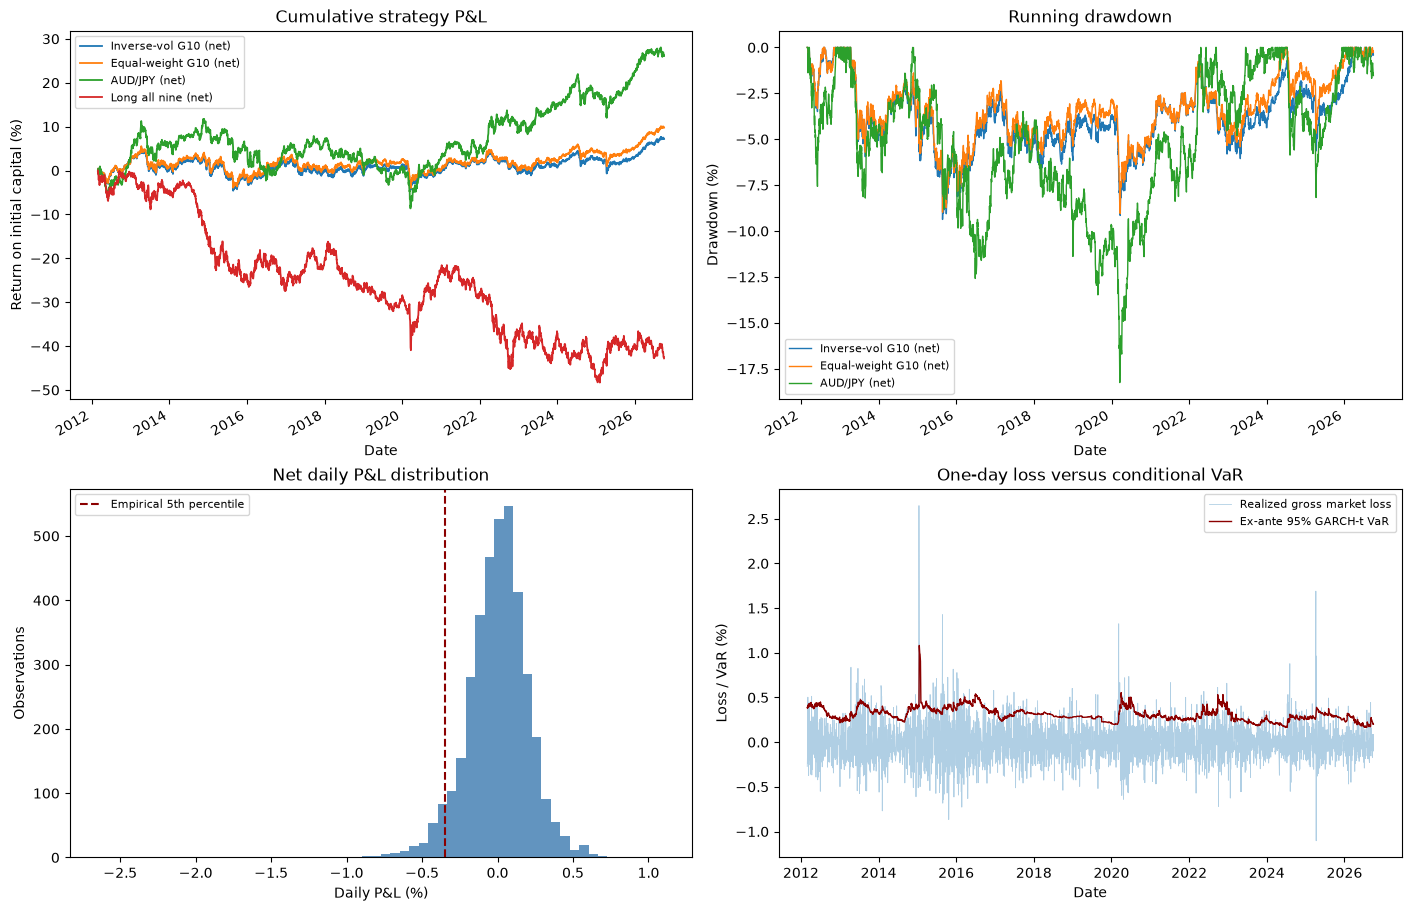

**VaR check:** 223 of 3,776 live days (5.9%) had gross market losses above the prior-close 95% VaR estimate. The latest estimate is **0.203%** for one day. A 95% VaR describes a loss threshold, not the worst possible loss.

In [15]:
tearsheet = performance_metrics(vol_net)
tearsheet["95% conditional VaR, latest 1-day (%)"] = float(wf["var95"].iloc[-1])
metric_order = [
    "annualized return (%)", "annualized volatility (%)", "Sharpe",
    "skewness", "excess kurtosis", "maximum drawdown (%)",
    "95% conditional VaR, latest 1-day (%)", "annualized turnover (x capital)",
    "total costs + spread (% initial capital)",
]
display(pd.DataFrame({"Metric": metric_order,
                      "Value": [tearsheet[k] for k in metric_order]}).set_index("Metric").round(3))

returns_for_chart = pd.DataFrame({
    "Inverse-vol G10 (net)": vol_net["net"],
    "Equal-weight G10 (net)": equal_net["net"],
    "AUD/JPY (net)": pair_net["net"],
    "Long all nine (net)": naive_net["net"],
})
wealth_paths = 1.0 + returns_for_chart.cumsum() / 100.0
wealth_anchor = pd.DataFrame(1.0, index=[returns_for_chart.index[0] - pd.Timedelta(days=1)],
                             columns=returns_for_chart.columns)
wealth_paths = pd.concat([wealth_anchor, wealth_paths])
cumulative_pnl = 100 * (wealth_paths - 1.0)
drawdown_paths = 100 * (wealth_paths / wealth_paths.cummax() - 1.0)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
cumulative_pnl.plot(ax=axes[0, 0], lw=1.3)
axes[0, 0].set(title="Cumulative strategy P&L", ylabel="Return on initial capital (%)", xlabel="Date")
axes[0, 0].legend(fontsize=8)
drawdown_paths[["Inverse-vol G10 (net)", "Equal-weight G10 (net)", "AUD/JPY (net)"]].plot(ax=axes[0, 1], lw=1)
axes[0, 1].set(title="Running drawdown", ylabel="Drawdown (%)", xlabel="Date")
axes[0, 1].legend(fontsize=8)
axes[1, 0].hist(vol_net["net"], bins=60, color="steelblue", alpha=0.85)
axes[1, 0].axvline(vol_net["net"].quantile(0.05), color="darkred", ls="--", label="Empirical 5th percentile")
axes[1, 0].set(title="Net daily P&L distribution", xlabel="Daily P&L (%)", ylabel="Observations")
axes[1, 0].legend(fontsize=8)
axes[1, 1].plot((-vol_net["gross"]).index, -vol_net["gross"], alpha=0.35, lw=0.6, label="Realized gross market loss")
axes[1, 1].plot(wf["var95"].index, wf["var95"], lw=1, color="darkred", label="Ex-ante 95% GARCH-t VaR")
axes[1, 1].set(title="One-day loss versus conditional VaR", ylabel="Loss / VaR (%)", xlabel="Date")
axes[1, 1].legend(fontsize=8)
plt.show()

breaches = ((-vol_net["gross"]) > wf["var95"]).sum()
display(Markdown(
    f"**VaR check:** {breaches:,} of {len(vol_net):,} live days "
    f"({100 * breaches / len(vol_net):.1f}%) had gross market losses above the prior-close 95% VaR estimate. "
    f"The latest estimate is **{wf['var95'].iloc[-1]:.3f}%** for one day. "
    "A 95% VaR describes a loss threshold, not the worst possible loss."
))

#### Carry-unwind episode: August 2024

The August 2024 JPY unwind is inside this sample if the downloaded source histories cover that month. The top panel below shows the **net** portfolio drawdown around that episode. The lower panel overlays **gross market losses** and the *previous-close* VaR that applied to each holding day, keeping deterministic charges out of both sides of the VaR comparison. The accompanying text checks whether the worst early-August gross loss exceeded its advance risk estimate and whether that estimate increased on the following trading day.

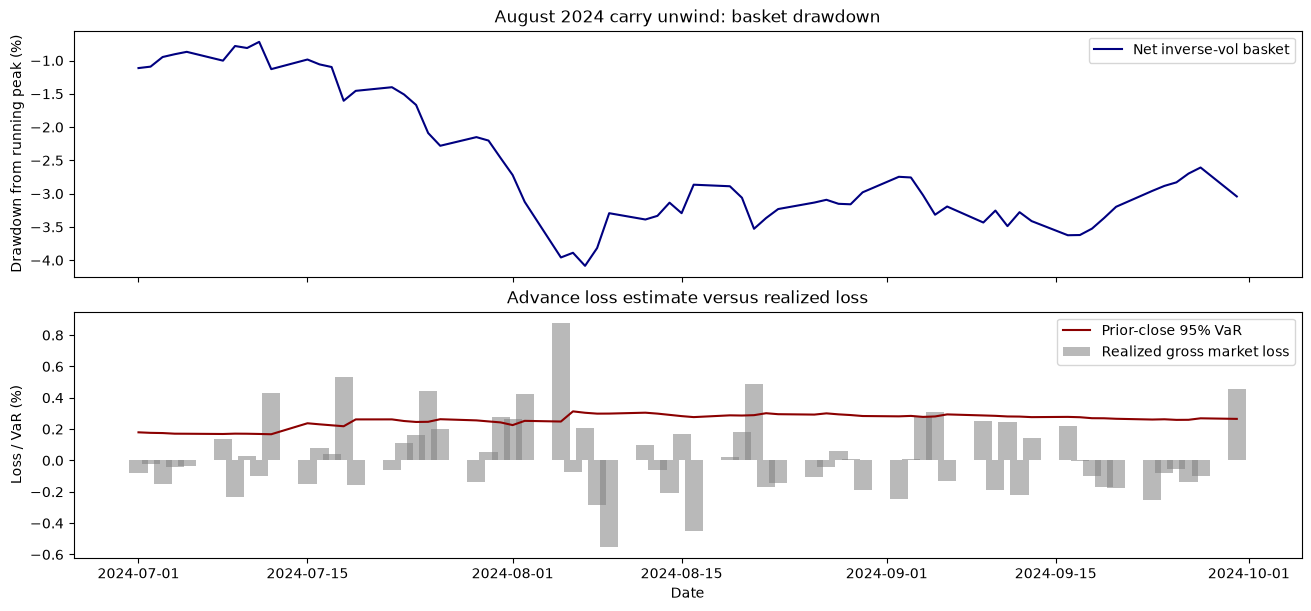

The worst gross market day from August 1–12 was **2024-08-05**, a **0.88%** loss. Its advance 95% VaR was **0.25%**, so the loss exceeded the model's threshold. July 15–31 median VaR was **0.25%**; the next holding day's VaR was **0.31%** and rose after the loss. The running drawdown reached **-4.08%** in this window. A higher post-shock forecast is a response to observed damage, not advance protection against it.

In [16]:
episode_start, episode_end = pd.Timestamp("2024-07-01"), pd.Timestamp("2024-09-30")
episode = vol_net.loc[episode_start:episode_end]
if len(episode) >= 10:
    episode_drawdown = drawdown_paths.loc[episode.index, "Inverse-vol G10 (net)"]
    local_var = wf["var95"].loc[episode.index]
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, constrained_layout=True)
    axes[0].plot(episode_drawdown.index, episode_drawdown, color="navy", label="Net inverse-vol basket")
    axes[0].set(title="August 2024 carry unwind: basket drawdown", ylabel="Drawdown from running peak (%)")
    axes[0].legend()
    axes[1].bar(episode.index, -episode["gross"], width=1.5, color="gray", alpha=0.55, label="Realized gross market loss")
    axes[1].plot(local_var.index, local_var, color="darkred", lw=1.5, label="Prior-close 95% VaR")
    axes[1].set(title="Advance loss estimate versus realized loss", ylabel="Loss / VaR (%)", xlabel="Date")
    axes[1].legend()
    plt.show()

    early_august = episode.loc["2024-08-01":"2024-08-12", "gross"]
    worst_date = early_august.idxmin()
    worst_loss = -float(early_august.min())
    predicted = float(local_var.loc[worst_date])
    later_dates = local_var.index[local_var.index > worst_date]
    next_var = float(local_var.loc[later_dates[0]]) if len(later_dates) else np.nan
    july_var = float(local_var.loc["2024-07-15":"2024-07-31"].median())
    breach_text = "exceeded" if worst_loss > predicted else "stayed below"
    reaction_text = ("rose after the loss" if next_var > predicted else "did not rise on the next holding day")
    display(Markdown(
        f"The worst gross market day from August 1–12 was **{worst_date.date()}**, a **{worst_loss:.2f}%** "
        f"loss. Its advance 95% VaR was **{predicted:.2f}%**, so the loss {breach_text} the "
        f"model's threshold. July 15–31 median VaR was **{july_var:.2f}%**; the next "
        f"holding day's VaR was **{next_var:.2f}%** and {reaction_text}. "
        f"The running drawdown reached **{episode_drawdown.min():.2f}%** in this window. A higher post-shock "
        "forecast is a response to observed damage, not advance protection against it."
    ))
else:
    display(Markdown("The source histories do not include enough July–September 2024 observations to assess the August 2024 carry unwind."))

### 5.3 Interpretation and PM decision

The following paragraphs are generated from the notebook's computed outputs, so the interpretation updates when the source data cache is refreshed. The recommendation is conditional on this historical sample and the stated cost assumptions.

In [17]:
eqm = performance_metrics(equal_net)
vm = performance_metrics(vol_net)
eg = performance_metrics(equal_gross)
vg = performance_metrics(vol_gross)
dd_eq = abs(eqm["maximum drawdown (%)"])
dd_vol = abs(vm["maximum drawdown (%)"])
dd_reduction = dd_eq - dd_vol
dd_comparison = (f"an improvement of {dd_reduction:.2f} percentage points"
                 if dd_reduction >= 0 else
                 f"a deterioration of {-dd_reduction:.2f} percentage points")
tail_change = vm["skewness"] - eqm["skewness"]
meaningful = dd_reduction > 0.15 * dd_eq and tail_change >= -0.1

display(Markdown(
    f"**Sizing and tail risk.** The equal-weight basket lost as much as **{dd_eq:.2f}%** "
    f"from peak to trough; inverse-vol sizing lost **{dd_vol:.2f}%**, "
    f"**{dd_comparison}** in maximum drawdown. "
    f"Their net skewness values were **{eqm['skewness']:.2f}** and **{vm['skewness']:.2f}**, "
    f"respectively; excess kurtosis was **{eqm['excess kurtosis']:.2f}** and "
    f"**{vm['excess kurtosis']:.2f}**. "
    + ("On those two measures the risk reduction was material, though this is still only a historical sample."
       if meaningful else "On these measures inverse-vol sizing did not deliver a clear, material tail-risk reduction.")
))

gross_vs_net = vg["annualized return (%)"] - vm["annualized return (%)"]
eq_gross_vs_net = eg["annualized return (%)"] - eqm["annualized return (%)"]
harsh_return = float(sensitivity.loc[("Inverse-vol", 10, 25), "annualized return (%)"])
if vg["annualized return (%)"] > 0 >= vm["annualized return (%)"]:
    friction_verdict = "The base-case costs reverse a positive gross mean into a negative net one."
elif vm["annualized return (%)"] > 0:
    friction_verdict = "The base-case costs narrow, but do not reverse, the positive gross mean."
else:
    friction_verdict = "The gross mean was already non-positive, and costs deepen that result."
display(Markdown(
    f"**Friction sensitivity.** At the base-case 5 bp trading charge and 10 bp annual spread, "
    f"inverse-vol annualized mean fell from **{vg['annualized return (%)']:.2f}%** gross "
    f"to **{vm['annualized return (%)']:.2f}%** net, a **{gross_vs_net:.2f}-point** drag. "
    f"Equal-weight fell by **{eq_gross_vs_net:.2f} points**. The sensitivity table above "
    f"puts the inverse-vol mean at **{harsh_return:.2f}%** with 10 bp turnover cost "
    f"and a 25 bp annual spread. {friction_verdict}"
))

worst_day = float(vol_net["net"].min())
premium_risk = vm["skewness"] < -0.5 or vm["excess kurtosis"] > 3 or breaches > 0.07 * len(vol_net)
description = ("a small premium exposed to occasional large losses" if premium_risk else
               "a modest historical edge with no especially strong negative-tail signal in this sample")
display(Markdown(
    f"**Shape of returns.** Net skewness is **{vm['skewness']:.2f}**, excess kurtosis "
    f"**{vm['excess kurtosis']:.2f}**, the worst day **{worst_day:.2f}%**, and maximum "
    f"drawdown **{vm['maximum drawdown (%)']:.2f}%**. With **{breaches}** advance 95% VaR "
    f"breaches, I describe this sample as **{description}**. The August 2024 panel gives "
    "the time ordering of one known unwind, which a single Sharpe number cannot show."
))

if vm["Sharpe"] > 0.5 and vm["annualized return (%)"] > 0 and vm["maximum drawdown (%)"] > -20:
    recommendation = "I would consider a small, monitored pilot allocation"
else:
    recommendation = "I would not allocate a full-risk live book on this evidence"
display(Markdown(
    f"**PM recommendation.** {recommendation}. The net annualized return is "
    f"**{vm['annualized return (%)']:.2f}%** with Sharpe **{vm['Sharpe']:.2f}** and "
    f"maximum drawdown **{vm['maximum drawdown (%)']:.2f}%**. A single change I would "
    "test first is a fixed-budget JPY call hedge against a funding-currency unwind, "
    "because the August 2024 loss exceeded the advance VaR estimate. I would price "
    "the option premium and require an out-of-sample reduction in tail losses before "
    "increasing capital."
))

**Sizing and tail risk.** The equal-weight basket lost as much as **9.04%** from peak to trough; inverse-vol sizing lost **9.37%**, **a deterioration of 0.32 percentage points** in maximum drawdown. Their net skewness values were **-0.87** and **-1.01**, respectively; excess kurtosis was **7.46** and **9.63**. On these measures inverse-vol sizing did not deliver a clear, material tail-risk reduction.

**Friction sensitivity.** At the base-case 5 bp trading charge and 10 bp annual spread, inverse-vol annualized mean fell from **0.65%** gross to **0.48%** net, a **0.17-point** drag. Equal-weight fell by **0.13 points**. The sensitivity table above puts the inverse-vol mean at **0.27%** with 10 bp turnover cost and a 25 bp annual spread. The base-case costs narrow, but do not reverse, the positive gross mean.

**Shape of returns.** Net skewness is **-1.01**, excess kurtosis **9.63**, the worst day **-2.65%**, and maximum drawdown **-9.37%**. With **223** advance 95% VaR breaches, I describe this sample as **a small premium exposed to occasional large losses**. The August 2024 panel gives the time ordering of one known unwind, which a single Sharpe number cannot show.

**PM recommendation.** I would not allocate a full-risk live book on this evidence. The net annualized return is **0.48%** with Sharpe **0.15** and maximum drawdown **-9.37%**. A single change I would test first is a fixed-budget JPY call hedge against a funding-currency unwind, because the August 2024 loss exceeded the advance VaR estimate. I would price the option premium and require an out-of-sample reduction in tail losses before increasing capital.

#### Saved Section 5 discussion and decision — data as of 2026-09-30

The net inverse-volatility basket's annualized mean is **0.48%**, volatility **3.33%**, and Sharpe **0.15**. Its skewness is **−1.01**, excess kurtosis **9.63**, and maximum drawdown **−9.37%**; costs and spread consume **2.49% of initial notional** over the 14.6-year live sample. The latest one-day GARCH-t 95% gross-market VaR is **0.203%**, and realized gross losses exceeded the advance threshold on **223 of 3,776** days (**5.9%**). The VaR is an approximate marginal-GARCH portfolio forecast and should not be mistaken for a crash-loss bound.

During the August 2024 JPY unwind, the worst early-August gross loss was **0.88% on August 5**, versus a prior-close VaR of **0.25%**. VaR rose to **0.31%** on the next holding day, after the loss. This is more consistent with collecting a small premium while bearing occasional large losses than with a smooth, dependable edge. I would **not recommend a full-risk allocation** from this evidence: the net Sharpe is low, the tails are adverse, and the alternative sizing did not reduce drawdown. The first change I would test is a fixed-budget JPY call hedge against a funding-currency unwind, with the option premium included and tail-risk improvement evaluated out of sample before any capital decision.


## Section 6 — Bonus: Three-Month Trend Overlay

At each *monthly* signal close I compare each selected currency's USD spot to its trailing 63-common-observation mean, calculated through that close. I retain a carry long only above its mean and a carry short only below its mean. Disallowed legs are set to zero; I **do not reallocate** their weight to surviving legs, so gross exposure may fall below 100% and the idle allocation earns USD cash, worth zero excess P&L in this framework. The rule is fixed before looking at the results, uses no future prices, and pays transaction/funding charges on the resulting positions exactly as above.

,annualized return (%),Sharpe,skewness,excess kurtosis,maximum drawdown (%),annualized turnover (x capital)
Inverse-vol carry,0.483,0.145,-1.011,9.632,-9.368,1.371
With 63-day trend,-0.420,-0.125,-0.922,12.342,-13.891,4.494


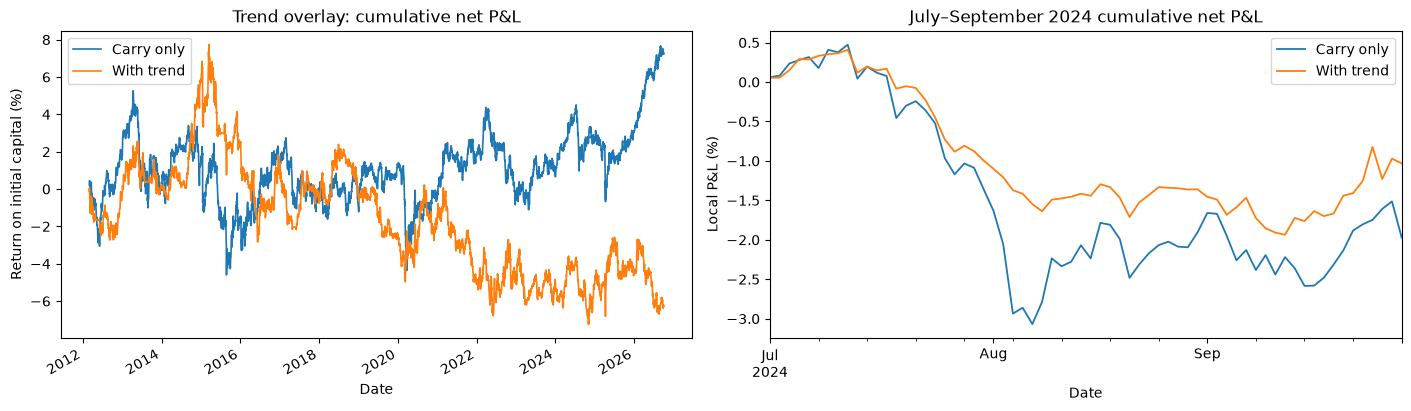

The overlay changed annualized return from **0.48%** to **-0.42%**, skewness from **-1.01** to **-0.92**, and maximum drawdown from **-9.37%** to **-13.89%** (increased drawdown by 4.52 percentage points). July–September 2024 modeled P&L was **-1.97%** without and **-1.03%** with the overlay. The added trend rule did not improve historical drawdown after costs.

In [18]:
trend_weights = pd.DataFrame(0.0, index=live_dates, columns=FOREIGN)
rebalance_dates = list(wf["rebalances"].index)
all_carry_dates = carry_pnl.index
for k, trade_date in enumerate(rebalance_dates):
    start_position = live_dates.get_loc(trade_date)
    end_position = live_dates.get_loc(rebalance_dates[k + 1]) if k + 1 < len(rebalance_dates) else len(live_dates)
    previous_close = all_carry_dates[all_carry_dates.get_loc(trade_date) - 1]
    recent_spot = spot_usd.loc[:previous_close, FOREIGN].tail(63)
    if len(recent_spot) < 63:
        raise ValueError("Trend overlay requires 63 known spot observations")
    base = weights_vol.loc[trade_date]
    current, average = recent_spot.iloc[-1], recent_spot.mean()
    allowed = ((base > 0) & (current > average)) | ((base < 0) & (current < average))
    trend_weights.iloc[start_position:end_position, :] = base.where(allowed, 0.0).to_numpy()

trend_net = backtest_weights(trend_weights, BASE_TRADING_BPS, BASE_FUNDING_BPS)
trend_metrics = performance_metrics(trend_net)
overlay_comparison = pd.DataFrame({
    "Inverse-vol carry": vm,
    "With 63-day trend": trend_metrics,
}).T
display(overlay_comparison[["annualized return (%)", "Sharpe", "skewness", "excess kurtosis",
                            "maximum drawdown (%)", "annualized turnover (x capital)"]].round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
pd.DataFrame({
    "Carry only": vol_net["net"].cumsum(),
    "With trend": trend_net["net"].cumsum(),
}).plot(ax=axes[0], lw=1.2)
axes[0].set(title="Trend overlay: cumulative net P&L", xlabel="Date", ylabel="Return on initial capital (%)")
pd.DataFrame({
    "Carry only": vol_net["net"].loc[episode_start:episode_end].cumsum(),
    "With trend": trend_net["net"].loc[episode_start:episode_end].cumsum(),
}).plot(ax=axes[1], lw=1.3)
axes[1].set(title="July–September 2024 cumulative net P&L", xlabel="Date", ylabel="Local P&L (%)")
plt.show()

episode_carry = vol_net["net"].loc[episode_start:episode_end].sum()
episode_trend = trend_net["net"].loc[episode_start:episode_end].sum()
dd_gain = abs(vm["maximum drawdown (%)"]) - abs(trend_metrics["maximum drawdown (%)"])
trend_dd_description = (f"reduced drawdown by {dd_gain:.2f} percentage points"
                        if dd_gain >= 0 else
                        f"increased drawdown by {-dd_gain:.2f} percentage points")
display(Markdown(
    f"The overlay changed annualized return from **{vm['annualized return (%)']:.2f}%** to "
    f"**{trend_metrics['annualized return (%)']:.2f}%**, skewness from "
    f"**{vm['skewness']:.2f}** to **{trend_metrics['skewness']:.2f}**, and maximum "
    f"drawdown from **{vm['maximum drawdown (%)']:.2f}%** to "
    f"**{trend_metrics['maximum drawdown (%)']:.2f}%** "
    f"({trend_dd_description}). "
    f"July–September 2024 modeled P&L was **{episode_carry:.2f}%** without and "
    f"**{episode_trend:.2f}%** with the overlay. "
    + ("The added trend rule improved historical drawdown after costs."
       if dd_gain > 0 else "The added trend rule did not improve historical drawdown after costs.")
))

#### Saved bonus discussion — data as of 2026-09-30

The 63-observation trend filter improves the July–September 2024 episode from **−1.97%** to **−1.03%** modeled P&L, but it does not improve the full sample. Annualized net return changes from **+0.48% to −0.42%**, maximum drawdown worsens from **−9.37% to −13.89%**, and annualized turnover rises from **1.37 to 4.49 times capital**. Skewness becomes slightly less negative (**−1.01 to −0.92**), while excess kurtosis rises (**9.63 to 12.34**). The extra trading and missed carry overwhelm this simple filter's local crash benefit; I would reject this version and test a different risk control before deployment.
